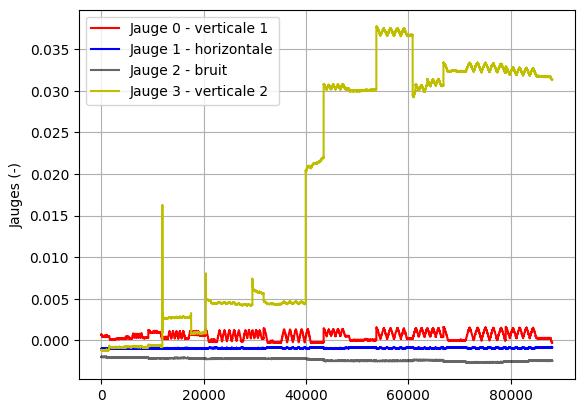

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

# MODIFICATION 1: accepte le nom original ou le nom créé lors du téléchargement.
data_candidates = ["Clean_data_1_E.csv", "Clean_data_1_E(1).csv"]
data_path = next((name for name in data_candidates if os.path.exists(name)), None)
if data_path is None:
    raise FileNotFoundError(
        "Placez Clean_data_1_E.csv dans le même dossier que le notebook."
    )

data = pd.read_csv(data_path)
columns_ = ["Temps (s)", "Depl (mm)",
            "Force (kN)", "Jauge 0", "Jauge 1", "Jauge 2", "Jauge 3"]
df = pd.DataFrame(data, columns=columns_)

# Configuration des jauges pour l'essai 2_A:
# Jauge 0: verticale locale 1
# Jauge 1: horizontale
# Jauge 2: bruit / jauge témoin
# Jauge 3: verticale locale 2
plt.plot(df["Jauge 0"], color="r", label="Jauge 0 - verticale 1")
plt.plot(df["Jauge 1"], color="b", label="Jauge 1 - horizontale")
plt.plot(df["Jauge 2"], color="k", alpha=0.6, label="Jauge 2 - bruit")
plt.plot(df["Jauge 3"], color="y", label="Jauge 3 - verticale 2")
plt.ylabel("Jauges (-)")
plt.grid()
plt.legend()
plt.show()


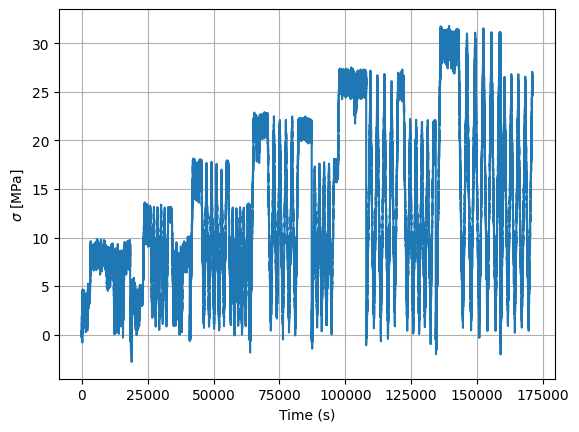

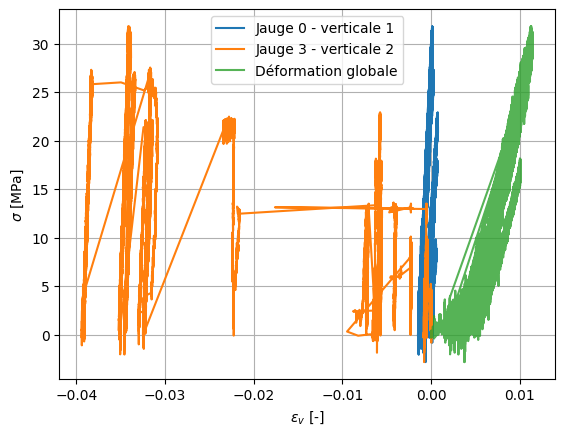

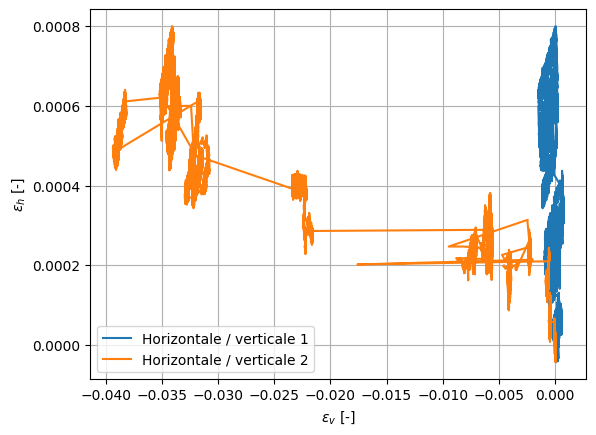

31.80511797736124


In [3]:
import os, math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import numpy as np

#----------------------------------------------------------------------------

def lsm_linear(L_y, L_x):
    '''
    Least square method to determine y = ax + b.
    '''
    # compute sums
    s_1 = 0
    s_2 = 0
    s_3 = 0
    s_4 = 0
    s_5 = 0
    for i in range(len(L_y)):
        s_1 = s_1 + 1*L_x[i]*L_x[i]
        s_2 = s_2 + 1*L_x[i]
        s_3 = s_3 + 1
        s_4 = s_4 + 1*L_x[i]*L_y[i]
        s_5 = s_5 + 1*L_y[i]
    # solve problem
    M = np.array([[s_1, s_2],[s_2, s_3]])
    V = np.array([s_4, s_5])
    result = np.linalg.solve(M, V)
    a = result[0]
    b = result[1]
    # correlation linear
    cov = 0
    vx = 0
    vy = 0
    for i in range(len(L_y)):
        cov = cov + (L_x[i]-np.mean(L_x))*(L_y[i]-np.mean(L_y))
        vx = vx + (L_x[i]-np.mean(L_x))*(L_x[i]-np.mean(L_x))
        vy = vy + (L_y[i]-np.mean(L_y))*(L_y[i]-np.mean(L_y))
    corr = cov/(math.sqrt(vx*vy))
    # compute sum of residuals square
    ei2 = 0
    for i in range(len(L_x)):
        ei2 = ei2 + (L_y[i]-(a*L_x[i]+b))**2
    # compute deviation
    s = math.sqrt(ei2/(len(L_x)-2))
    # compute standard deviation
    s_a = s/math.sqrt(vx)
    s_b = s*math.sqrt(1/len(L_x)+np.mean(L_x)**2/vx)
    # compute R2
    s_fit = vy - ei2
    R2 = s_fit/vy

    return a, b, corr, s_a, s_b, R2

#----------------------------------------------------------------------------

# MODIFICATION 4: la fonction transporte maintenant les 2 déformations locales et la déformation globale.
def extract_cycles(stress, size_window, delta_data, x0, x1):
    '''
    Post-process the stress to extract a group of cycles.
    '''
    # init
    counter = 0

    # create a filter and save iterations
    stress_pp = []
    eps_v_pp = []
    eps_v1_pp = []
    eps_vglobal_pp = []
    eps_h_pp = []
    iter_to_saved = []

    # iterate on the data
    for i in range(x0,len(stress[:x1])):
        # extract the data in a small time window
        data_i = stress[i: i+size_window]
        if max(data_i)-min(data_i) > delta_data:
            # this is a part of a cycle
            stress_pp.append(data_i[i])
            eps_v_pp.append(eps_v[i])
            eps_v1_pp.append(eps_v1[i])
            eps_vglobal_pp.append(eps_vglobal[i])
            eps_h_pp.append(eps_h[i])
            iter_to_saved.append(i)
            counter = 0
        else :
            counter = counter + 1
            if counter < size_window :
                # this is still a part of the cycle
                stress_pp.append(data_i[i])
                eps_v_pp.append(eps_v[i])
                eps_v1_pp.append(eps_v1[i])
                eps_vglobal_pp.append(eps_vglobal[i])
                eps_h_pp.append(eps_h[i])
                iter_to_saved.append(i)
            else :
                # this is not a part of a cycle
                pass
    return stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp

#----------------------------------------------------------------------------

def box_min_max(
    stress_pp,
    threshold,
    n_ite_min_start_stop,
    n_ite_min_stop_start,
    min_span_fraction=0.80
):
    """
    Determine the unloading and loading phases using
    the min-max criterion.

    The detected intervals are restricted to the region
    located between the lower and upper stress limits.

    Incomplete residual branches are rejected.
    """

    stress_pp = np.asarray(stress_pp)

    # Characteristic stress values
    mean_stress = np.mean(stress_pp)
    min_stress = np.min(stress_pp)
    max_stress = np.max(stress_pp)

    half_amplitude = (
        max_stress - min_stress
    ) / 2

    lower_limit = (
        mean_stress
        - threshold * half_amplitude
    )

    upper_limit = (
        mean_stress
        + threshold * half_amplitude
    )

    box_height = upper_limit - lower_limit

    # Output intervals
    L_iters_cycle_load = []
    L_iters_cycle_unload = []

    search_start_unload = True
    search_start_load = False

    i_end_detection = 0
    i_start = None

    for i in range(len(stress_pp)):

        inside_box = (
            lower_limit
            <= stress_pp[i]
            <= upper_limit
        )

        # Search for the first detected branch
        if search_start_unload and not search_start_load:

            if inside_box:

                if (
                    i - i_end_detection
                    > n_ite_min_stop_start
                ):
                    search_start_unload = False
                    i_start = i

        # Search for the following branches
        elif not search_start_unload and search_start_load:

            if inside_box:

                if (
                    i - i_end_detection
                    > n_ite_min_stop_start
                ):
                    search_start_load = False
                    i_start = i

        # Search for the end of the current branch
        elif not search_start_unload and not search_start_load:

            if not inside_box:

                if (
                    i_start is not None
                    and i - i_start
                    > n_ite_min_start_stop
                ):

                    # i is already outside the grey limits.
                    # The last valid point is therefore i - 1.
                    i_last_inside = i - 1

                    branch_stress_span = abs(
                        stress_pp[i_last_inside]
                        - stress_pp[i_start]
                    )

                    # Prepare detection of the next branch
                    search_start_load = True
                    i_end_detection = i

                    # Reject incomplete residual branches
                    if (
                        branch_stress_span
                        < min_span_fraction * box_height
                    ):
                        continue

                    # Classification of the valid branch
                    if (
                        stress_pp[i_start]
                        > stress_pp[i_last_inside]
                    ):
                        L_iters_cycle_unload.append(
                            [i_start, i_last_inside]
                        )

                    else:
                        L_iters_cycle_load.append(
                            [i_start, i_last_inside]
                        )

    return (
        L_iters_cycle_load,
        L_iters_cycle_unload
    )

def loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load):
    '''
    Postprocess the loading phase. It determines the maximum stress, the Young, the poisson and the initial strain.
    '''
    L_poisson_l = []
    L_R2_P_l = []
    L_E_l = []
    L_R2_E_l = []
    L_strain_l = []
    # iterate on the cycle
    for i_load in range(len(L_iters_cycle_load)):
        # extract start-end of the phase
        i_start_i = L_iters_cycle_load[i_load][0]
        i_end_i = L_iters_cycle_load[i_load][1]
        # MODIFICATION 4b: ignore intervals that cannot support a linear regression.
        axial_i = eps_v_pp[i_start_i: i_end_i+1]
        horizontal_i = eps_h_pp[i_start_i: i_end_i+1]
        stress_i = stress_pp[i_start_i: i_end_i+1]
        if (len(axial_i) < 3
                or np.isclose(np.ptp(axial_i), 0.0)
                or np.isclose(np.ptp(horizontal_i), 0.0)
                or np.isclose(np.ptp(stress_i), 0.0)):
            continue
        # fit
        poisson, def0, corr, s_poisson, s_def0, R2_P = lsm_linear(horizontal_i, axial_i)
        E, sig0, corr, s_E, s_sig0, R2_E = lsm_linear(stress_i, axial_i)
        strain_init = eps_v_pp[i_start_i]
        # save
        L_poisson_l.append(poisson)
        L_R2_P_l.append(R2_P)
        L_E_l.append(E)
        L_R2_E_l.append(R2_E)
        L_strain_l.append(strain_init)
    return L_E_l, L_poisson_l, L_strain_l, L_R2_E_l, L_R2_P_l

#----------------------------------------------------------------------------

def unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload):
    '''
    Postprocess the unloading phase. It determines the maximum stress, the Young, the poisson and the final strain.
    '''
    L_poisson_u = []
    L_E_u = []
    L_R2_E_u = []
    L_strain_u = []
    L_R2_P_u = []
    # iterate on the cycle
    for i_unload in range(len(L_iters_cycle_unload)):
        # extract start-end of the phase
        i_start_i = L_iters_cycle_unload[i_unload][0]
        i_end_i = L_iters_cycle_unload[i_unload][1]
        # MODIFICATION 4b: ignore intervals that cannot support a linear regression.
        axial_i = eps_v_pp[i_start_i: i_end_i+1]
        horizontal_i = eps_h_pp[i_start_i: i_end_i+1]
        stress_i = stress_pp[i_start_i: i_end_i+1]
        if (len(axial_i) < 3
                or np.isclose(np.ptp(axial_i), 0.0)
                or np.isclose(np.ptp(horizontal_i), 0.0)
                or np.isclose(np.ptp(stress_i), 0.0)):
            continue
        # fit
        poisson, def0, corr, s_poisson, s_def0, R2_P = lsm_linear(horizontal_i, axial_i)
        E, sig0, corr, s_E, s_sig0, R2_E = lsm_linear(stress_i, axial_i)
        strain_end = eps_v_pp[i_end_i]
        # save
        L_poisson_u.append(poisson)
        L_R2_P_u.append(R2_P)
        L_E_u.append(E)
        L_R2_E_u.append(R2_E)
        L_strain_u.append(strain_end)
    return L_E_u, L_poisson_u, L_strain_u, L_R2_E_u, L_R2_P_u

#----------------------------------------------------------------------------

def mean_R2(L_Pi, L_R2):
    """
    Compute the mean value weighted by R².

    Returns np.nan when there is no valid result or when
    the total statistical weight is zero.
    """
    values = np.asarray(L_Pi, dtype=float)
    weights = np.asarray(L_R2, dtype=float)

    if len(values) == 0 or len(weights) == 0:
        return np.nan

    if len(values) != len(weights):
        raise ValueError(
            "L_Pi and L_R2 must have the same length."
        )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not np.any(valid):
        return np.nan

    return np.average(
        values[valid],
        weights=weights[valid]
    )
#----------------------------------------------------------------------------

# MODIFICATION 2: lecture robuste du fichier et correspondance correcte des 4 jauges.
data_candidates = ["Clean_data_1_E.csv", "Clean_data_1_E(1).csv"]
data_path = next((name for name in data_candidates if os.path.exists(name)), None)
if data_path is None:
    raise FileNotFoundError(
        "Placez Clean_data_1_E.csv dans le même dossier que le notebook."
    )

data = pd.read_csv(data_path)
columns_ = ["Temps (s)", "Depl (mm)",
            "Force (kN)", "Jauge 0", "Jauge 1", "Jauge 2", "Jauge 3"]

# read the data from the test
df = pd.DataFrame(data, columns=columns_)

# Subtract the reference gauge (Jauge 2).
jauge02 = df["Jauge 0"] - df["Jauge 2"]  # vertical local strain 1
jauge12 = df["Jauge 1"] - df["Jauge 2"]  # horizontal strain
jauge32 = df["Jauge 3"] - df["Jauge 2"]  # vertical local strain 2

# Offset of the gauges.
jauge02 = jauge02 - jauge02.iloc[0]
jauge12 = jauge12 - jauge12.iloc[0]
jauge32 = jauge32 - jauge32.iloc[0]

# Sign convention:
# axial compression and transverse expansion are taken as positive.
jauge02 = -jauge02
jauge32 = -jauge32

# Stress.
section_sample = 0.001111103  # m2
stress = df["Force (kN)"] / section_sample  # kPa

# Cut the final part of the test, as in the original notebook.
n_cut_end = 3000
jauge02 = jauge02.iloc[:-n_cut_end].reset_index(drop=True)
jauge12 = jauge12.iloc[:-n_cut_end].reset_index(drop=True)
jauge32 = jauge32.iloc[:-n_cut_end].reset_index(drop=True)
stress = stress.iloc[:-n_cut_end].reset_index(drop=True)
temps = df["Temps (s)"].iloc[:-n_cut_end].reset_index(drop=True)
depl = df["Depl (mm)"].iloc[:-n_cut_end].reset_index(drop=True)

def nearest_time_index(time_series, target_time):
    """
    Return the index of the measurement whose time
    is closest to target_time.
    """
    time_values = time_series.to_numpy(dtype=float)

    return int(
        np.argmin(
            np.abs(time_values - target_time)
        )
    )

# Assign the local strains.
eps_v = jauge02.copy()   # Jauge 0: vertical local strain 1
eps_h = jauge12.copy()   # Jauge 1: horizontal strain
eps_v1 = jauge32.copy()  # Jauge 3: vertical local strain 2

# MODIFICATION 3: global axial strain obtained from the machine displacement.
# IMPORTANT: replace 80.0 by the measured initial specimen height, in mm.
h0_mm = 73.51
eps_vglobal = (depl - depl.iloc[0]) / h0_mm

# Plot the data.
plt.plot(temps, stress / 1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel("Time (s)")
plt.grid()
plt.show()

plt.plot(eps_v, stress / 1e3, label="Jauge 0 - verticale 1")
plt.plot(eps_v1, stress / 1e3, label="Jauge 3 - verticale 2")
plt.plot(eps_vglobal, stress / 1e3, label="Déformation globale", alpha=0.8)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r"$\epsilon_v$ [-]")
plt.grid()
plt.legend()
plt.show()

plt.plot(eps_v, eps_h, label="Horizontale / verticale 1")
plt.plot(eps_v1, eps_h, label="Horizontale / verticale 2")
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r"$\epsilon_v$ [-]")
plt.grid()
plt.legend()
plt.show()

print(np.max(stress) / 1e3)


p1: 1.8 MPa - small cycles
Requested time interval: 9500.00 s -> 11000.00 s
Nearest available times: 9499.49 s -> 10999.02 s
Corresponding row indices: 4750 -> 5498
Number of selected rows: 749


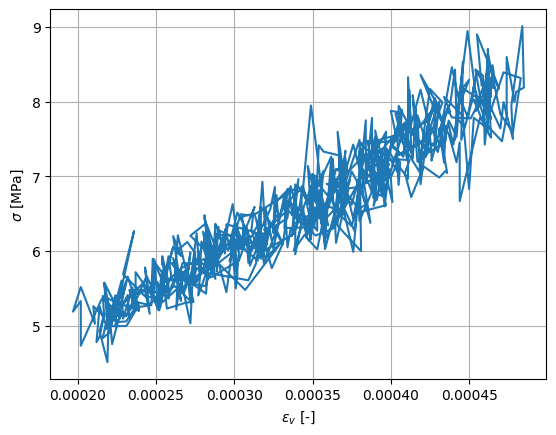

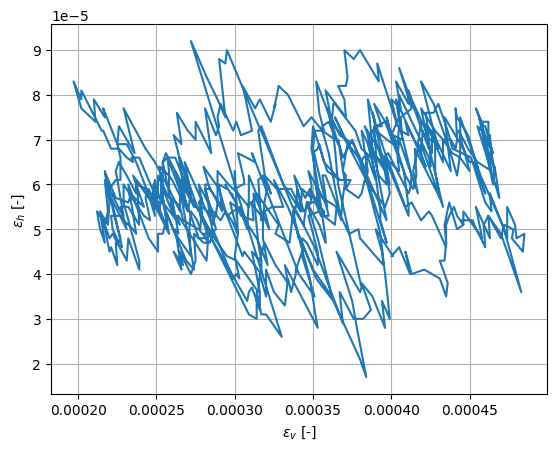

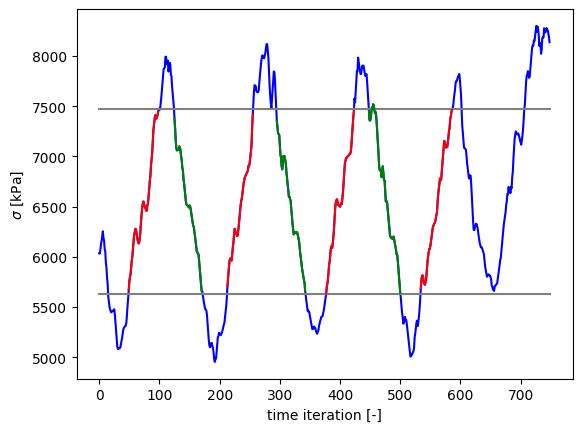

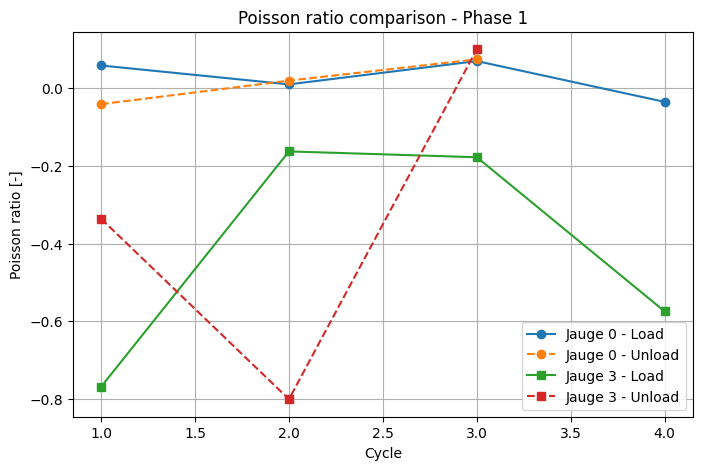

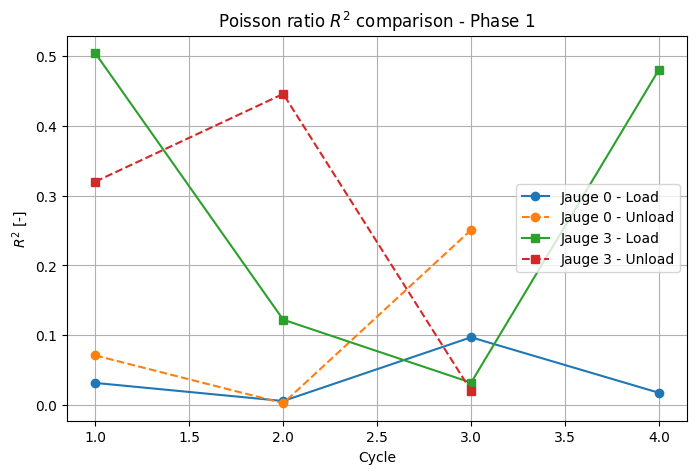

Poisson - Jauge 0: 0.053 - 0.048
Poisson - Jauge 3: -0.605 - -0.588


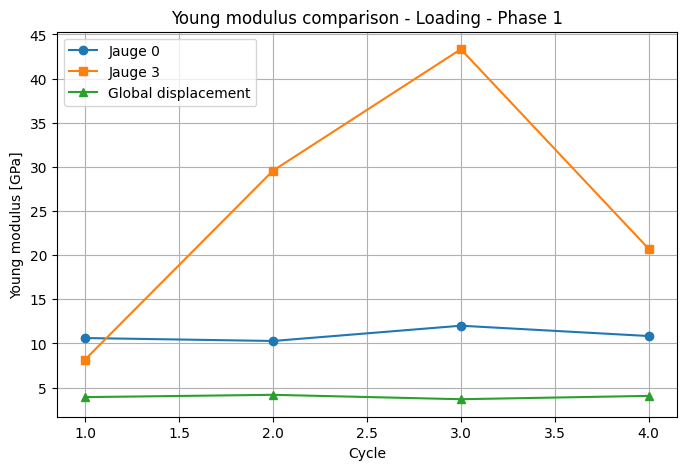

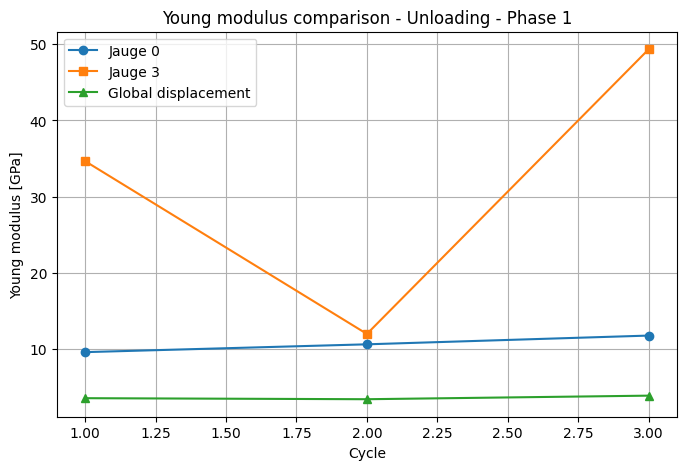

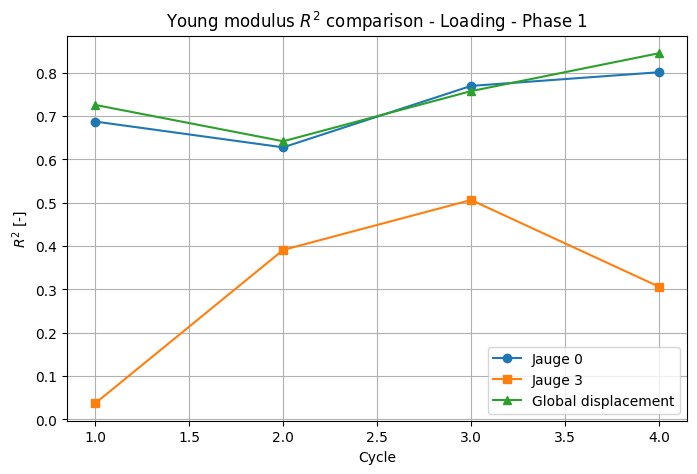

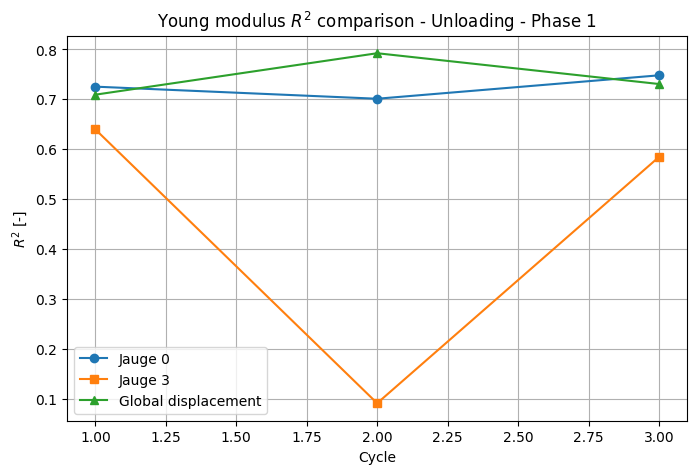

Young - Jauge 0 [GPa]: 10.97 - 10.71
Young - Jauge 3 [GPa]: 32.35 - 39.62
Young - Global [GPa]: 3.95 - 3.66


In [4]:
print('p1:', round(2/section_sample/1e3,2), 'MPa - small cycles')

# Times selected visually from the global time plot
t0 = 9500  # s
t1 = 11000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p1, poisson_l_p1, strain_l_p1, R2_E_l_p1, R2_P_l_p1 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p1, poisson_u_p1, strain_u_p1, R2_E_u_p1, R2_P_u_p1 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p1, poisson_l_v3_p1, strain_l_v3_p1, R2_E_l_v3_p1, R2_P_l_v3_p1 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p1, poisson_u_v3_p1, strain_u_v3_p1, R2_E_u_v3_p1, R2_P_u_v3_p1 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p1, _, strain_l_global_p1, R2_E_l_global_p1, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p1, _, strain_u_global_p1, R2_E_u_global_p1, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p1) + 1),
    poisson_l_p1,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p1) + 1),
    poisson_u_p1,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p1) + 1),
    poisson_l_v3_p1,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p1) + 1),
    poisson_u_v3_p1,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 1')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p1) + 1),
    R2_P_l_p1,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p1) + 1),
    R2_P_u_p1,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p1) + 1),
    R2_P_l_v3_p1,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p1) + 1),
    R2_P_u_v3_p1,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 1')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p1, R2_P_l_p1), 3),
    '-',
    round(mean_R2(poisson_u_p1, R2_P_u_p1), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p1, R2_P_l_v3_p1), 3),
    '-',
    round(mean_R2(poisson_u_v3_p1, R2_P_u_v3_p1), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p1) + 1),
    np.asarray(E_l_p1) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p1) + 1),
    np.asarray(E_l_v3_p1) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p1) + 1),
    np.asarray(E_l_global_p1) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 1')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p1) + 1),
    np.asarray(E_u_p1) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p1) + 1),
    np.asarray(E_u_v3_p1) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p1) + 1),
    np.asarray(E_u_global_p1) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 1')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p1) + 1),
    R2_E_l_p1,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p1) + 1),
    R2_E_l_v3_p1,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p1) + 1),
    R2_E_l_global_p1,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 1')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p1) + 1),
    R2_E_u_p1,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p1) + 1),
    R2_E_u_v3_p1,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p1) + 1),
    R2_E_u_global_p1,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 1')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p1, R2_E_l_p1) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p1, R2_E_u_p1) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p1, R2_E_l_v3_p1) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p1, R2_E_u_v3_p1) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p1, R2_E_l_global_p1) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p1, R2_E_u_global_p1) / 1e6, 2)
)

p2: 1.8 MPa - big cycles
Requested time interval: 11800.00 s -> 16500.00 s
Nearest available times: 11799.19 s -> 16499.70 s
Corresponding row indices: 5898 -> 8232
Number of selected rows: 2335


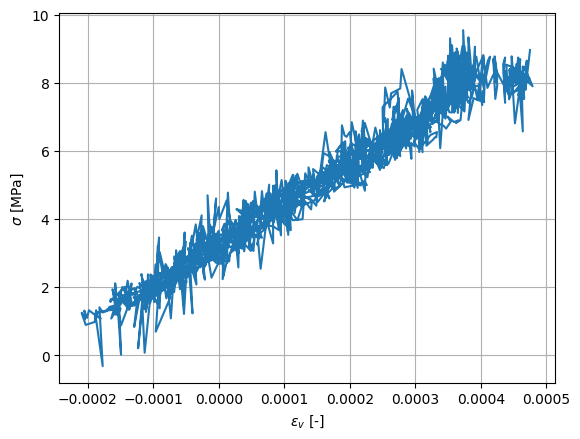

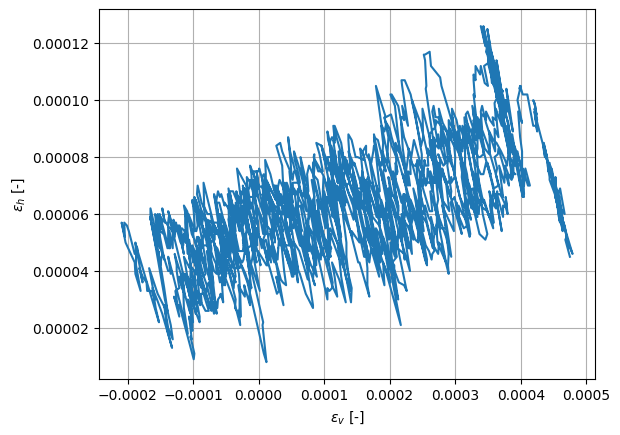

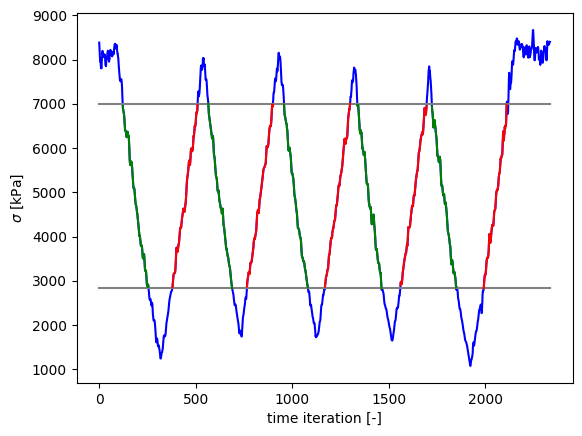

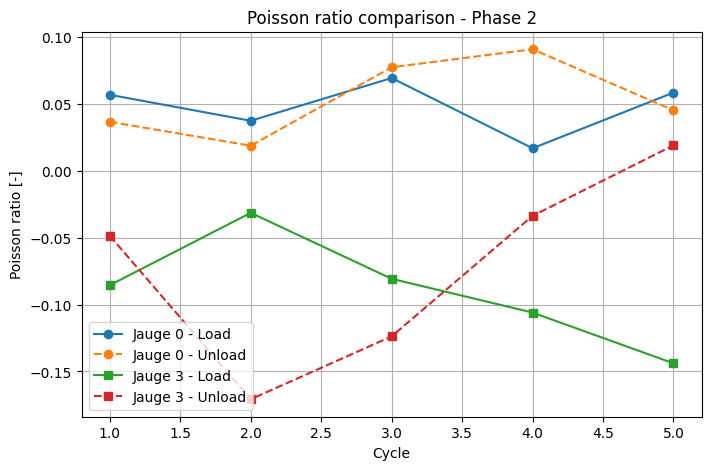

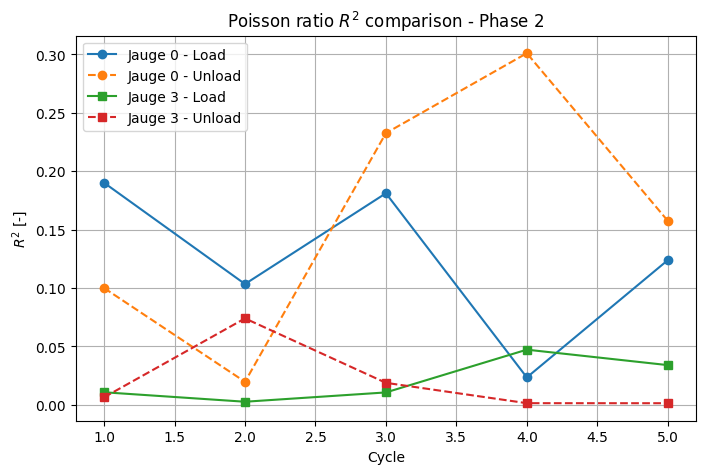

Poisson - Jauge 0: 0.056 - 0.07
Poisson - Jauge 3: -0.112 - -0.15


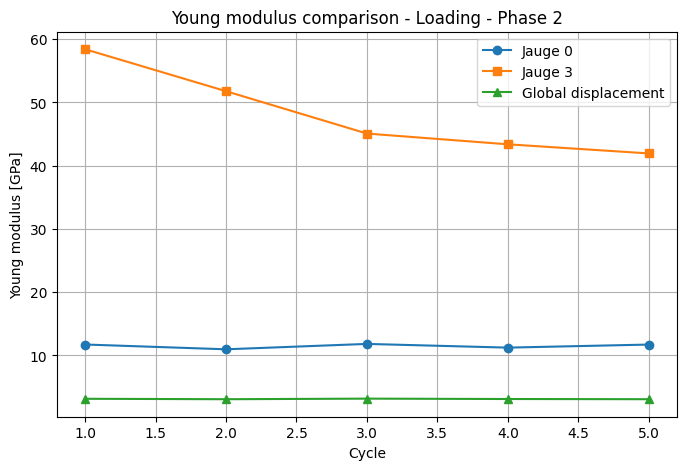

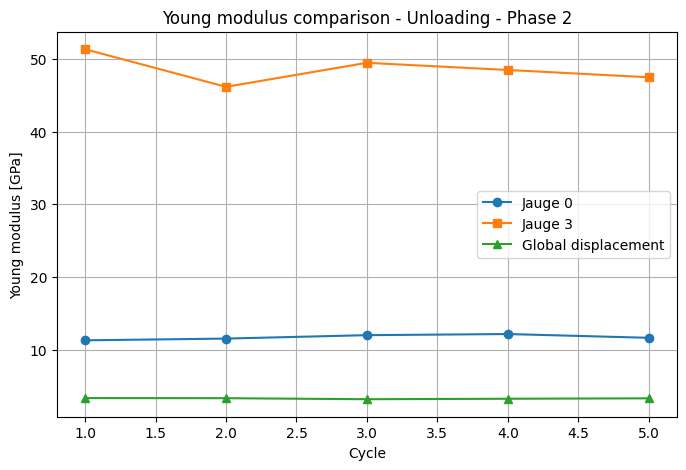

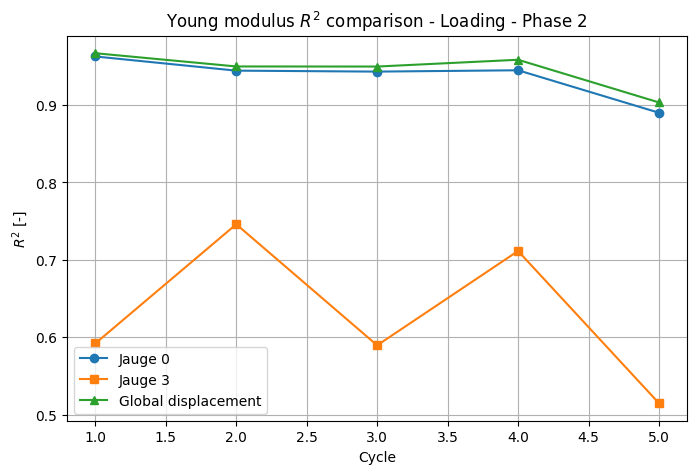

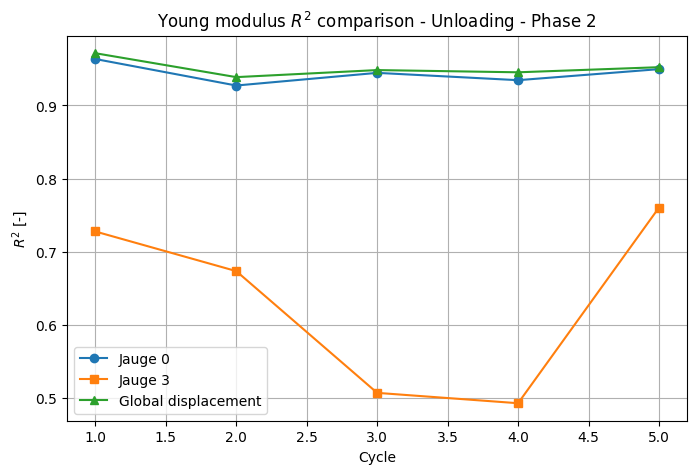

Young - Jauge 0 [GPa]: 11.5 - 11.71
Young - Jauge 3 [GPa]: 48.27 - 48.58
Young - Global [GPa]: 3.12 - 3.27


In [5]:
print('p2:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 11800  # s
t1 = 16500  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p2, poisson_l_p2, strain_l_p2, R2_E_l_p2, R2_P_l_p2 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p2, poisson_u_p2, strain_u_p2, R2_E_u_p2, R2_P_u_p2 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p2, poisson_l_v3_p2, strain_l_v3_p2, R2_E_l_v3_p2, R2_P_l_v3_p2 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p2, poisson_u_v3_p2, strain_u_v3_p2, R2_E_u_v3_p2, R2_P_u_v3_p2 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p2, _, strain_l_global_p2, R2_E_l_global_p2, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p2, _, strain_u_global_p2, R2_E_u_global_p2, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p2) + 1),
    poisson_l_p2,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p2) + 1),
    poisson_u_p2,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p2) + 1),
    poisson_l_v3_p2,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p2) + 1),
    poisson_u_v3_p2,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 2')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p2) + 1),
    R2_P_l_p2,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p2) + 1),
    R2_P_u_p2,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p2) + 1),
    R2_P_l_v3_p2,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p2) + 1),
    R2_P_u_v3_p2,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 2')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p2, R2_P_l_p2), 3),
    '-',
    round(mean_R2(poisson_u_p2, R2_P_u_p2), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p2, R2_P_l_v3_p2), 3),
    '-',
    round(mean_R2(poisson_u_v3_p2, R2_P_u_v3_p2), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p2) + 1),
    np.asarray(E_l_p2) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p2) + 1),
    np.asarray(E_l_v3_p2) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p2) + 1),
    np.asarray(E_l_global_p2) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 2')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p2) + 1),
    np.asarray(E_u_p2) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p2) + 1),
    np.asarray(E_u_v3_p2) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p2) + 1),
    np.asarray(E_u_global_p2) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 2')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p2) + 1),
    R2_E_l_p2,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p2) + 1),
    R2_E_l_v3_p2,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p2) + 1),
    R2_E_l_global_p2,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 2')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p2) + 1),
    R2_E_u_p2,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p2) + 1),
    R2_E_u_v3_p2,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p2) + 1),
    R2_E_u_global_p2,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 2')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p2, R2_E_l_p2) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p2, R2_E_u_p2) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p2, R2_E_l_v3_p2) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p2, R2_E_u_v3_p2) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p2, R2_E_l_global_p2) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p2, R2_E_u_global_p2) / 1e6, 2)
)

p3: 1.8 MPa - small cycles
Requested time interval: 24000.00 s -> 25800.00 s
Nearest available times: 24000.24 s -> 25799.96 s
Corresponding row indices: 11972 -> 12869
Number of selected rows: 898


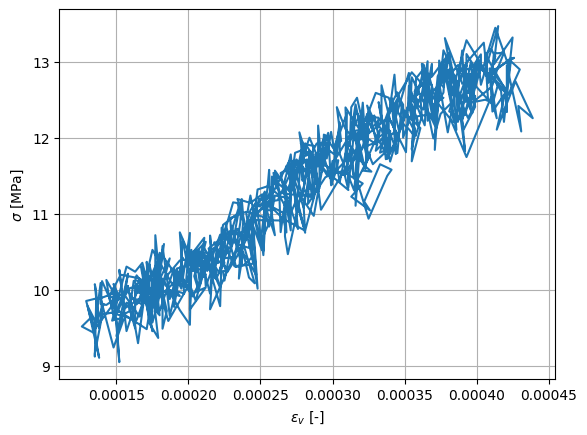

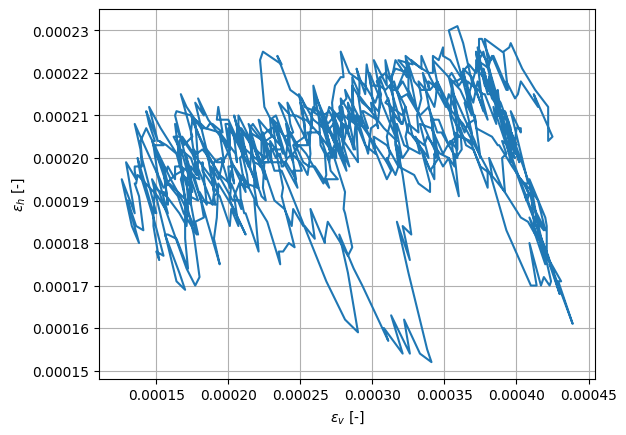

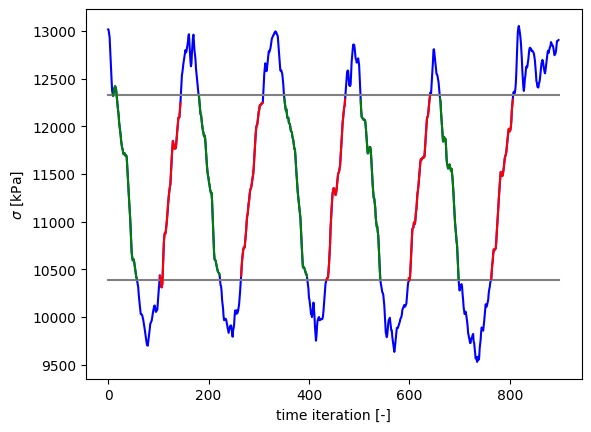

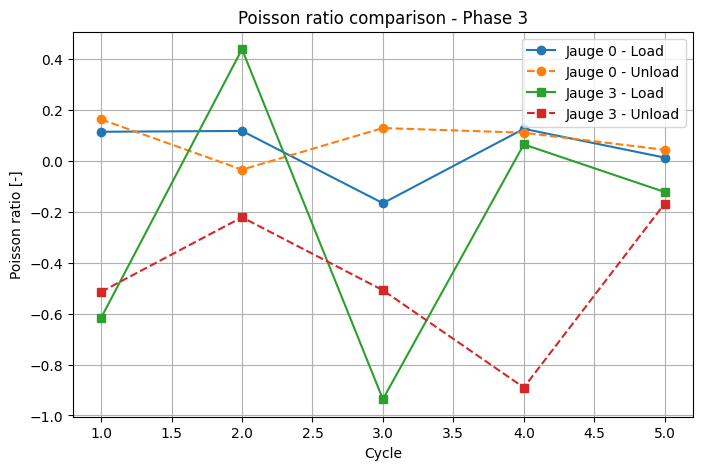

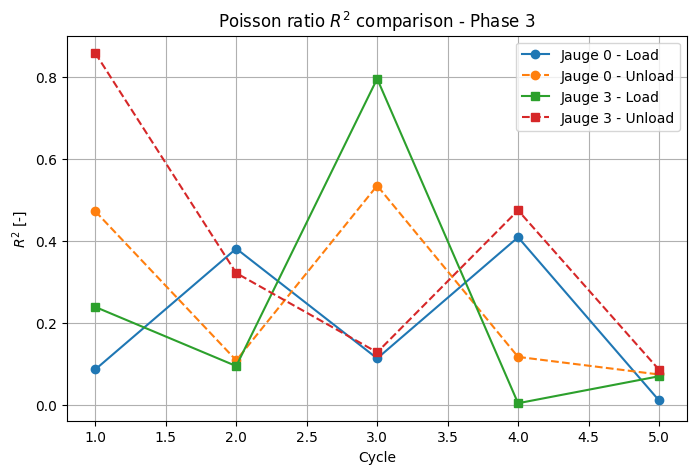

Poisson - Jauge 0: 0.088 - 0.122
Poisson - Jauge 3: -0.712 - -0.543


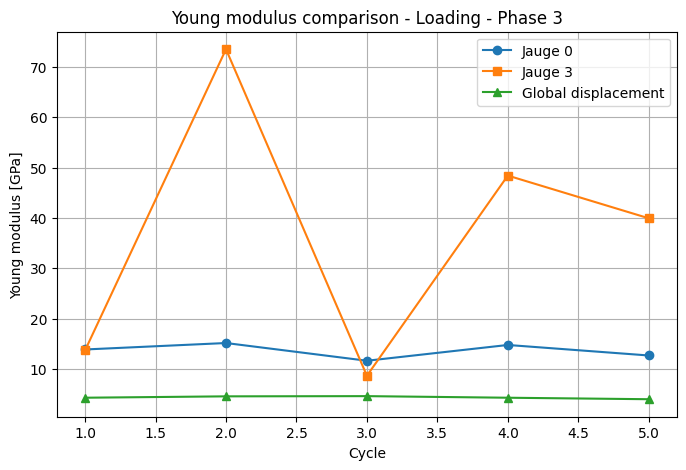

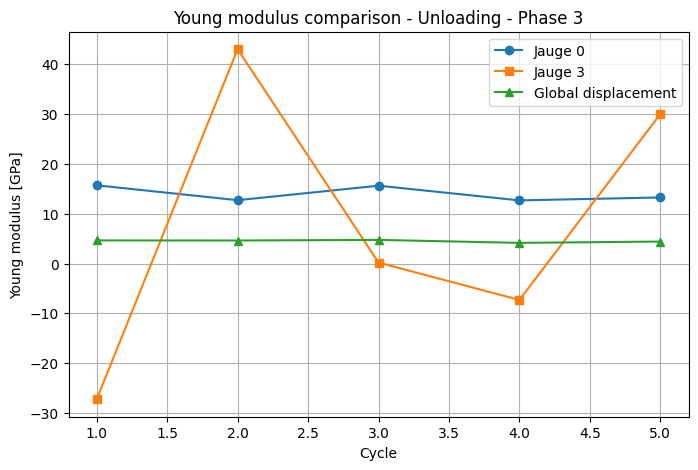

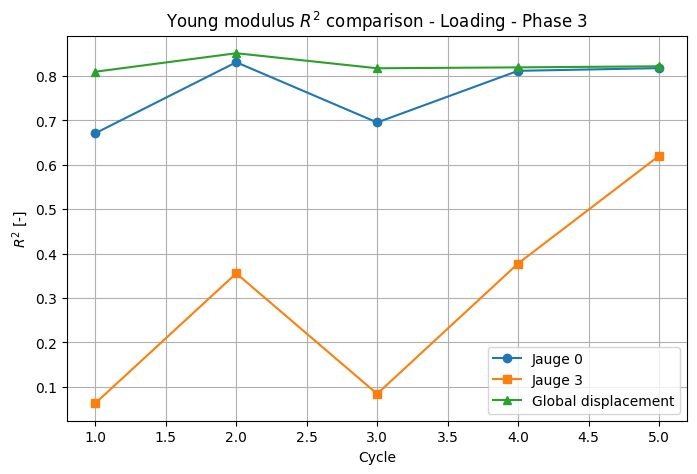

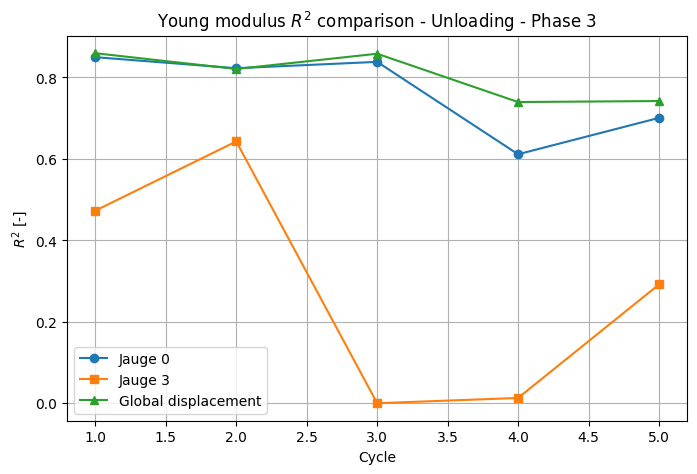

Young - Jauge 0 [GPa]: 13.67 - 14.1
Young - Jauge 3 [GPa]: 47.17 - 16.49
Young - Global [GPa]: 4.34 - 4.52


In [6]:
print('p3:', round(2/section_sample/1e3,2), 'MPa - small cycles')

# Times selected visually from the global time plot
t0 = 24000  # s
t1 = 25800  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p3, poisson_l_p3, strain_l_p3, R2_E_l_p3, R2_P_l_p3 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p3, poisson_u_p3, strain_u_p3, R2_E_u_p3, R2_P_u_p3 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p3, poisson_l_v3_p3, strain_l_v3_p3, R2_E_l_v3_p3, R2_P_l_v3_p3 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p3, poisson_u_v3_p3, strain_u_v3_p3, R2_E_u_v3_p3, R2_P_u_v3_p3 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p3, _, strain_l_global_p3, R2_E_l_global_p3, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p3, _, strain_u_global_p3, R2_E_u_global_p3, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p3) + 1),
    poisson_l_p3,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p3) + 1),
    poisson_u_p3,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p3) + 1),
    poisson_l_v3_p3,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p3) + 1),
    poisson_u_v3_p3,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 3')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p3) + 1),
    R2_P_l_p3,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p3) + 1),
    R2_P_u_p3,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p3) + 1),
    R2_P_l_v3_p3,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p3) + 1),
    R2_P_u_v3_p3,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 3')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p3, R2_P_l_p3), 3),
    '-',
    round(mean_R2(poisson_u_p3, R2_P_u_p3), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p3, R2_P_l_v3_p3), 3),
    '-',
    round(mean_R2(poisson_u_v3_p3, R2_P_u_v3_p3), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p3) + 1),
    np.asarray(E_l_p3) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p3) + 1),
    np.asarray(E_l_v3_p3) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p3) + 1),
    np.asarray(E_l_global_p3) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 3')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p3) + 1),
    np.asarray(E_u_p3) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p3) + 1),
    np.asarray(E_u_v3_p3) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p3) + 1),
    np.asarray(E_u_global_p3) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 3')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p3) + 1),
    R2_E_l_p3,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p3) + 1),
    R2_E_l_v3_p3,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p3) + 1),
    R2_E_l_global_p3,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 3')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p3) + 1),
    R2_E_u_p3,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p3) + 1),
    R2_E_u_v3_p3,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p3) + 1),
    R2_E_u_global_p3,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 3')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p3, R2_E_l_p3) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p3, R2_E_u_p3) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p3, R2_E_l_v3_p3) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p3, R2_E_u_v3_p3) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p3, R2_E_l_global_p3) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p3, R2_E_u_global_p3) / 1e6, 2)
)

p4: 1.8 MPa - big cycles
Requested time interval: 25800.00 s -> 33000.00 s
Nearest available times: 25799.96 s -> 33000.15 s
Corresponding row indices: 12869 -> 16442
Number of selected rows: 3574


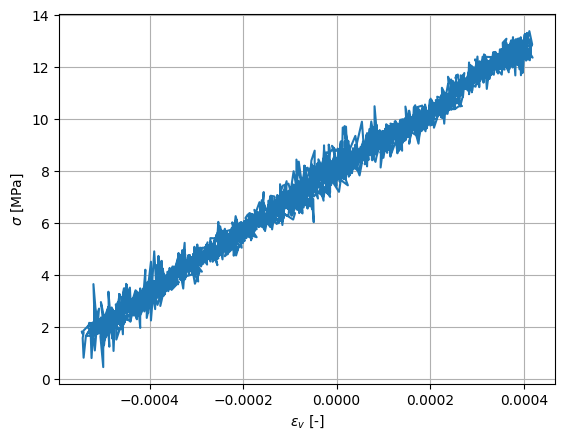

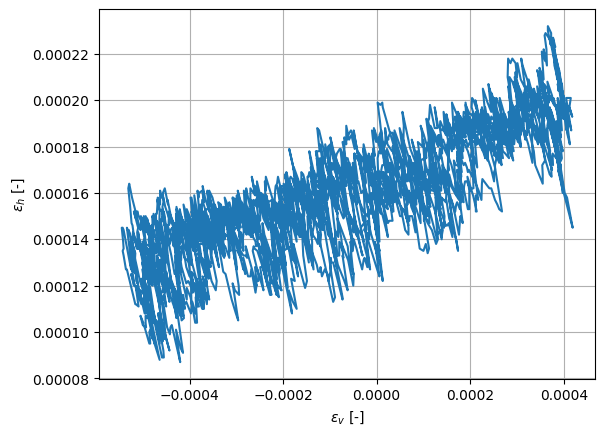

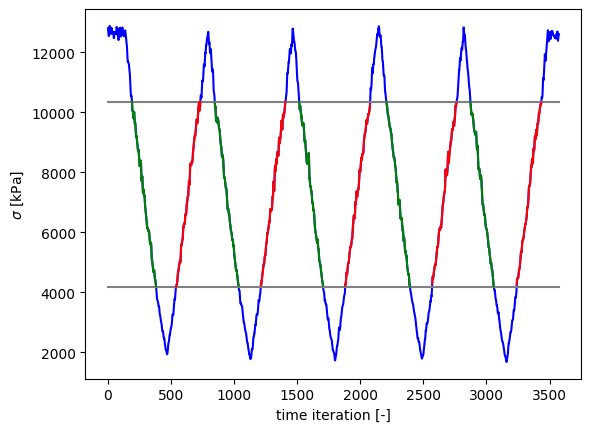

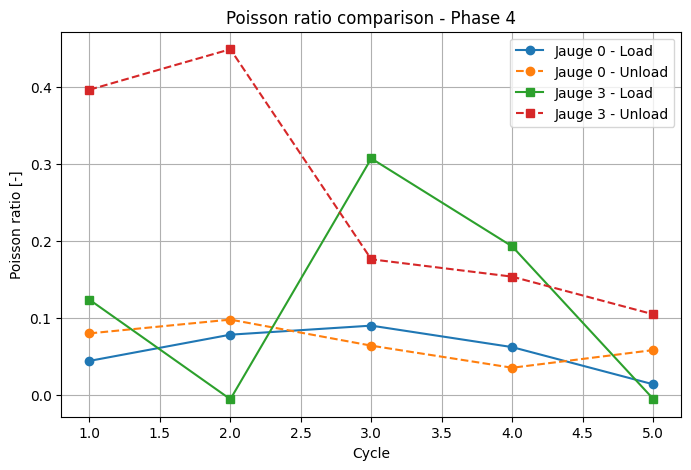

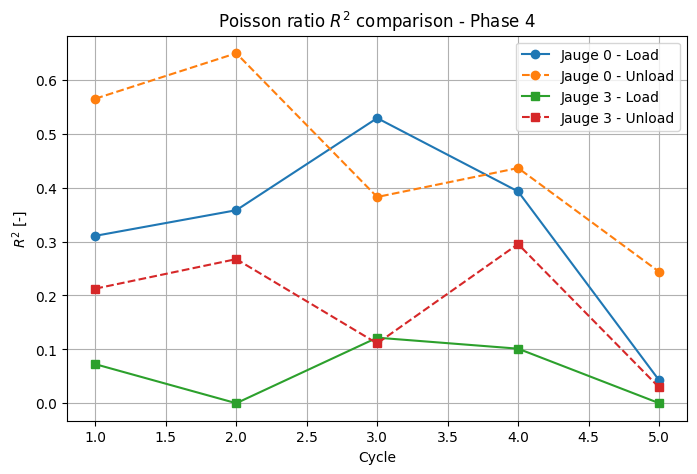

Poisson - Jauge 0: 0.07 - 0.071
Poisson - Jauge 3: 0.223 - 0.298


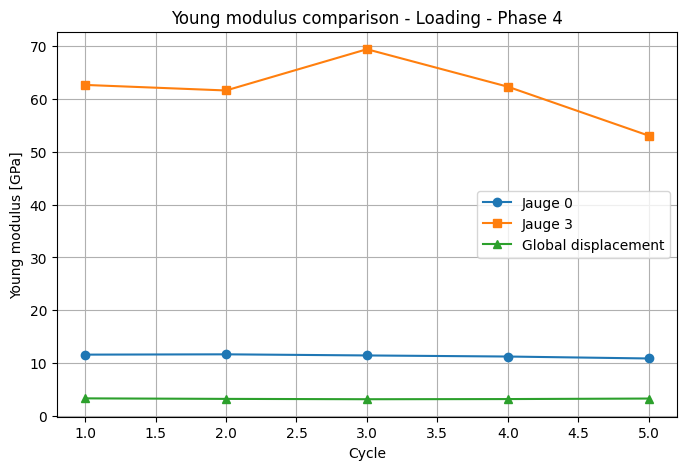

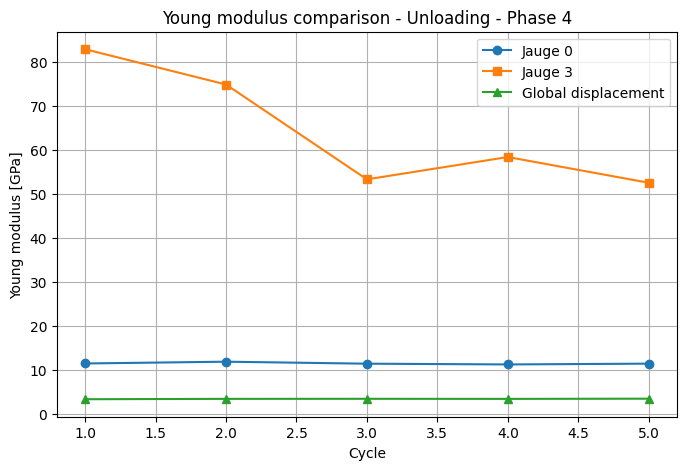

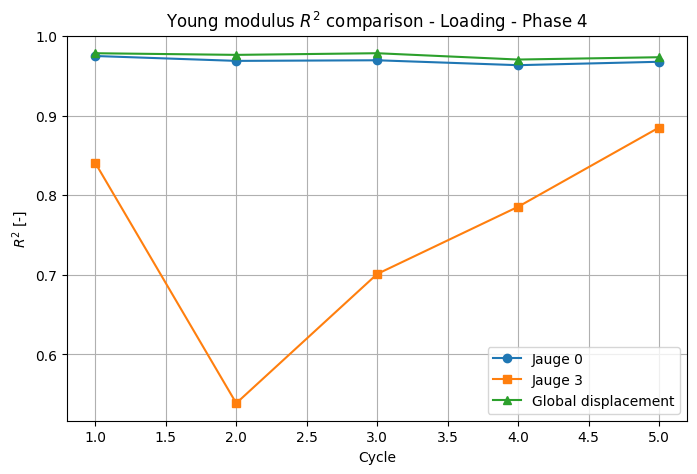

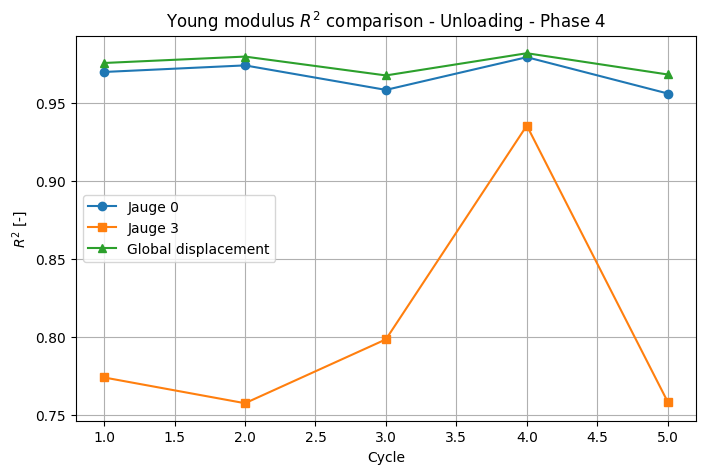

Young - Jauge 0 [GPa]: 11.36 - 11.46
Young - Jauge 3 [GPa]: 61.44 - 64.07
Young - Global [GPa]: 3.23 - 3.39


In [7]:
print('p4:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 25800  # s
t1 = 33000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p4, poisson_l_p4, strain_l_p4, R2_E_l_p4, R2_P_l_p4 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p4, poisson_u_p4, strain_u_p4, R2_E_u_p4, R2_P_u_p4 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p4, poisson_l_v3_p4, strain_l_v3_p4, R2_E_l_v3_p4, R2_P_l_v3_p4 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p4, poisson_u_v3_p4, strain_u_v3_p4, R2_E_u_v3_p4, R2_P_u_v3_p4 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p4, _, strain_l_global_p4, R2_E_l_global_p4, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p4, _, strain_u_global_p4, R2_E_u_global_p4, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p4) + 1),
    poisson_l_p4,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p4) + 1),
    poisson_u_p4,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p4) + 1),
    poisson_l_v3_p4,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p4) + 1),
    poisson_u_v3_p4,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 4')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p4) + 1),
    R2_P_l_p4,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p4) + 1),
    R2_P_u_p4,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p4) + 1),
    R2_P_l_v3_p4,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p4) + 1),
    R2_P_u_v3_p4,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 4')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p4, R2_P_l_p4), 3),
    '-',
    round(mean_R2(poisson_u_p4, R2_P_u_p4), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p4, R2_P_l_v3_p4), 3),
    '-',
    round(mean_R2(poisson_u_v3_p4, R2_P_u_v3_p4), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p4) + 1),
    np.asarray(E_l_p4) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p4) + 1),
    np.asarray(E_l_v3_p4) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p4) + 1),
    np.asarray(E_l_global_p4) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 4')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p4) + 1),
    np.asarray(E_u_p4) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p4) + 1),
    np.asarray(E_u_v3_p4) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p4) + 1),
    np.asarray(E_u_global_p4) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 4')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p4) + 1),
    R2_E_l_p4,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p4) + 1),
    R2_E_l_v3_p4,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p4) + 1),
    R2_E_l_global_p4,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 4')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p4) + 1),
    R2_E_u_p4,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p4) + 1),
    R2_E_u_v3_p4,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p4) + 1),
    R2_E_u_global_p4,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 4')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p4, R2_E_l_p4) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p4, R2_E_u_p4) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p4, R2_E_l_v3_p4) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p4, R2_E_u_v3_p4) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p4, R2_E_l_global_p4) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p4, R2_E_u_global_p4) / 1e6, 2)
)

p5: 1.8 MPa - medium cycles
Requested time interval: 34400.00 s -> 39040.00 s
Nearest available times: 34400.53 s -> 39040.95 s
Corresponding row indices: 17144 -> 19444
Number of selected rows: 2301


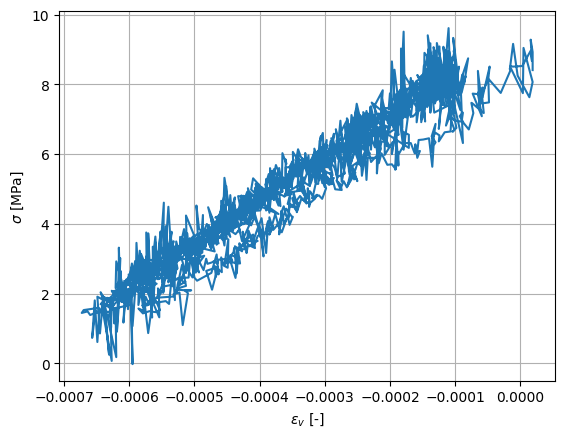

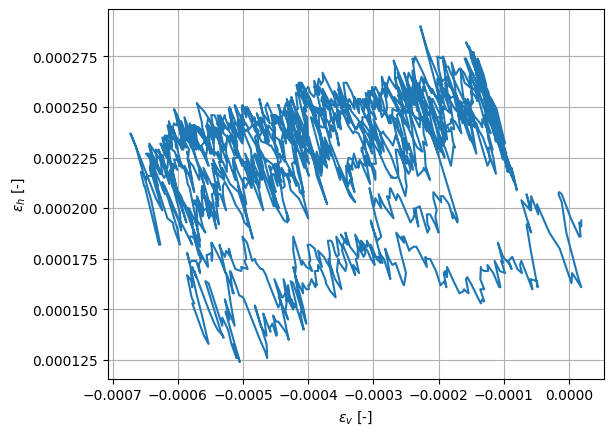

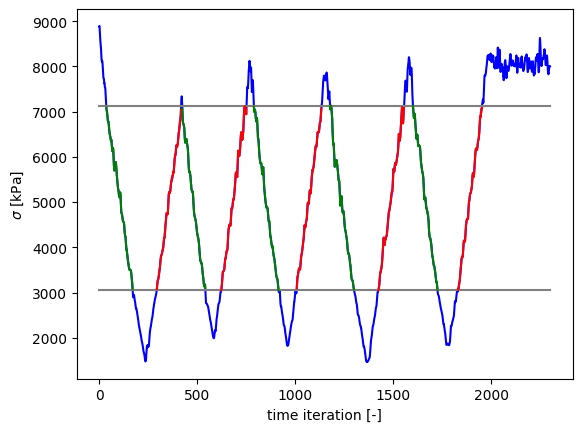

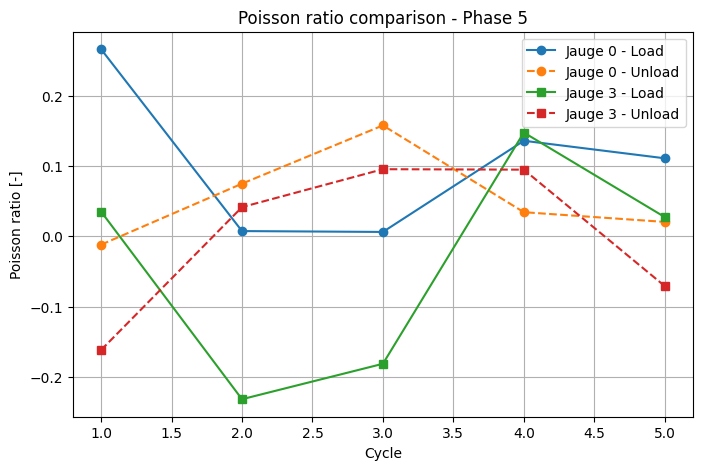

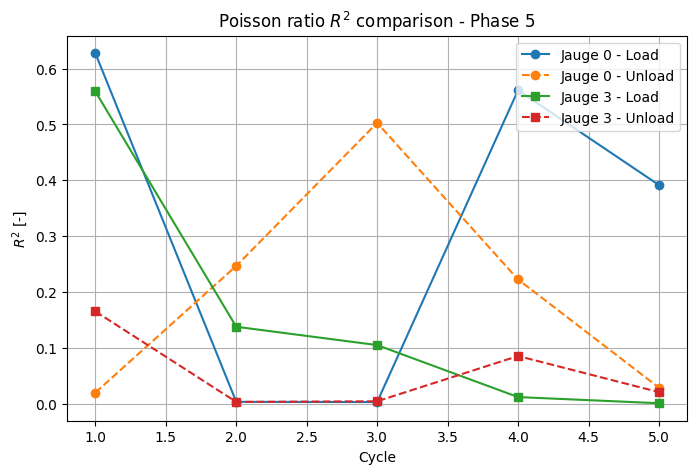

Poisson - Jauge 0: 0.181 - 0.104
Poisson - Jauge 3: -0.036 - -0.07


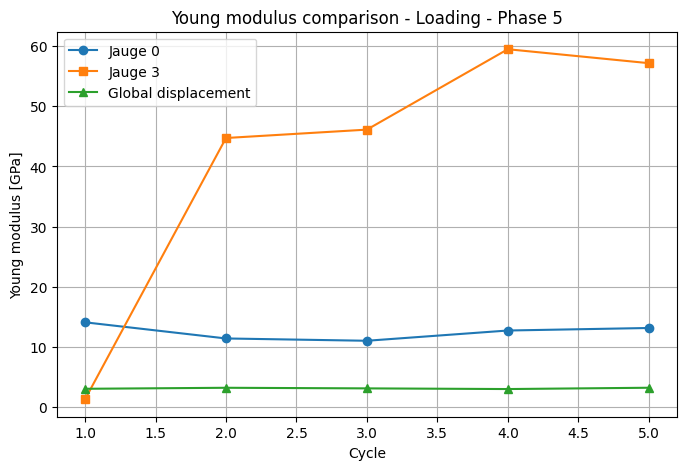

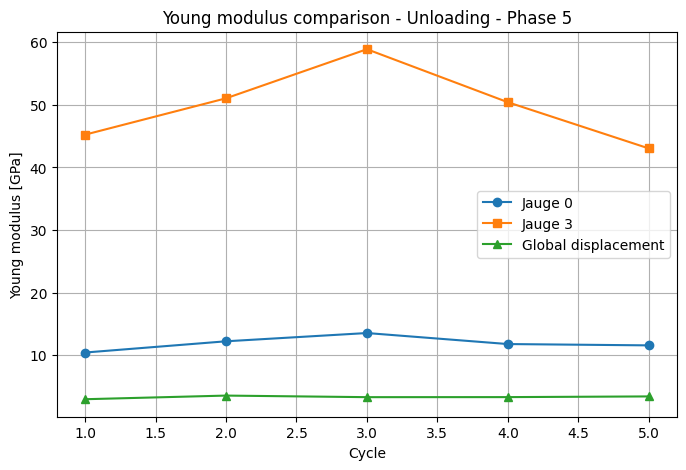

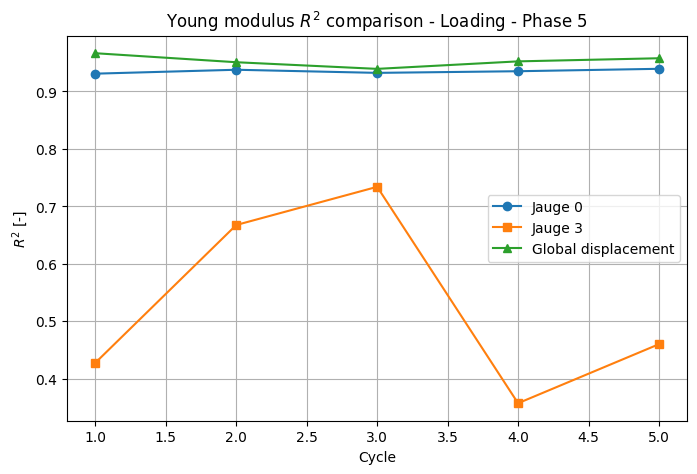

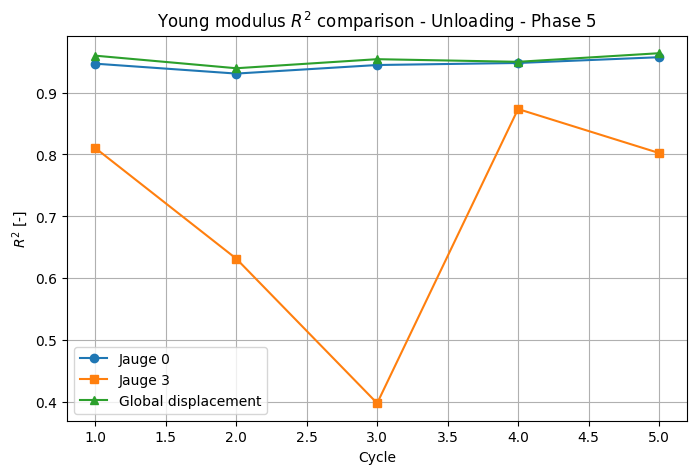

Young - Jauge 0 [GPa]: 12.5 - 11.9
Young - Jauge 3 [GPa]: 42.26 - 48.61
Young - Global [GPa]: 3.15 - 3.29


In [8]:
print('p5:', round(2/section_sample/1e3,2), 'MPa - medium cycles')

# Times selected visually from the global time plot
t0 = 34400  # s
t1 = 39040  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p5, poisson_l_p5, strain_l_p5, R2_E_l_p5, R2_P_l_p5 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p5, poisson_u_p5, strain_u_p5, R2_E_u_p5, R2_P_u_p5 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p5, poisson_l_v3_p5, strain_l_v3_p5, R2_E_l_v3_p5, R2_P_l_v3_p5 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p5, poisson_u_v3_p5, strain_u_v3_p5, R2_E_u_v3_p5, R2_P_u_v3_p5 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p5, _, strain_l_global_p5, R2_E_l_global_p5, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p5, _, strain_u_global_p5, R2_E_u_global_p5, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p5) + 1),
    poisson_l_p5,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p5) + 1),
    poisson_u_p5,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p5) + 1),
    poisson_l_v3_p5,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p5) + 1),
    poisson_u_v3_p5,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 5')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p5) + 1),
    R2_P_l_p5,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p5) + 1),
    R2_P_u_p5,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p5) + 1),
    R2_P_l_v3_p5,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p5) + 1),
    R2_P_u_v3_p5,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 5')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p5, R2_P_l_p5), 3),
    '-',
    round(mean_R2(poisson_u_p5, R2_P_u_p5), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p5, R2_P_l_v3_p5), 3),
    '-',
    round(mean_R2(poisson_u_v3_p5, R2_P_u_v3_p5), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p5) + 1),
    np.asarray(E_l_p5) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p5) + 1),
    np.asarray(E_l_v3_p5) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p5) + 1),
    np.asarray(E_l_global_p5) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 5')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p5) + 1),
    np.asarray(E_u_p5) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p5) + 1),
    np.asarray(E_u_v3_p5) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p5) + 1),
    np.asarray(E_u_global_p5) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 5')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p5) + 1),
    R2_E_l_p5,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p5) + 1),
    R2_E_l_v3_p5,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p5) + 1),
    R2_E_l_global_p5,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 5')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p5) + 1),
    R2_E_u_p5,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p5) + 1),
    R2_E_u_v3_p5,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p5) + 1),
    R2_E_u_global_p5,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 5')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p5, R2_E_l_p5) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p5, R2_E_u_p5) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p5, R2_E_l_v3_p5) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p5, R2_E_u_v3_p5) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p5, R2_E_l_global_p5) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p5, R2_E_u_global_p5) / 1e6, 2)
)

p6: 1.8 MPa - small cycles
Requested time interval: 42800.00 s -> 44800.00 s
Nearest available times: 42799.31 s -> 44800.60 s
Corresponding row indices: 21317 -> 22318
Number of selected rows: 1002


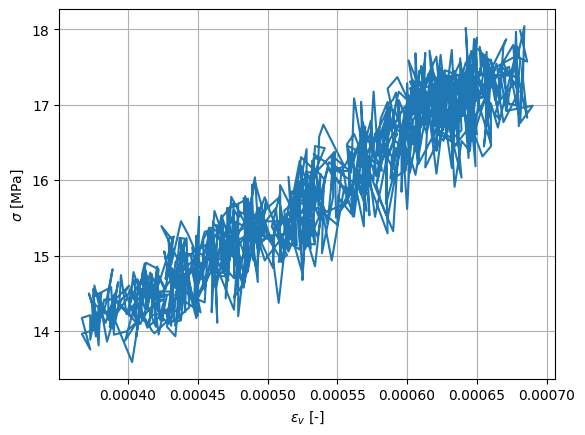

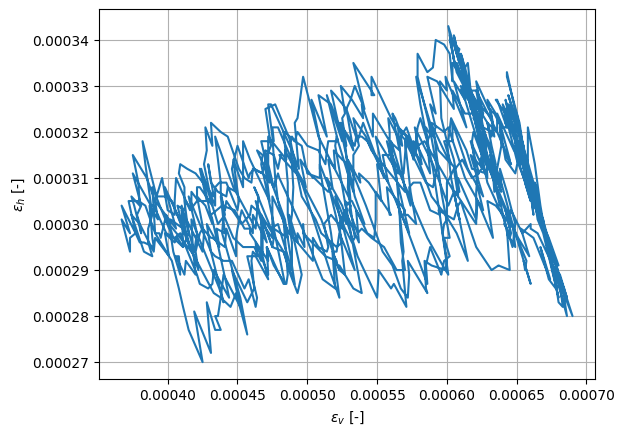

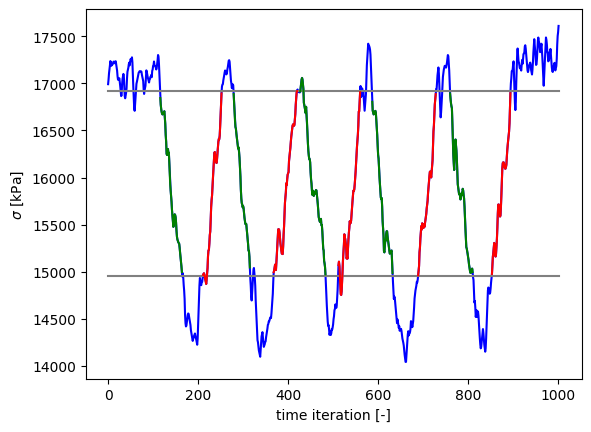

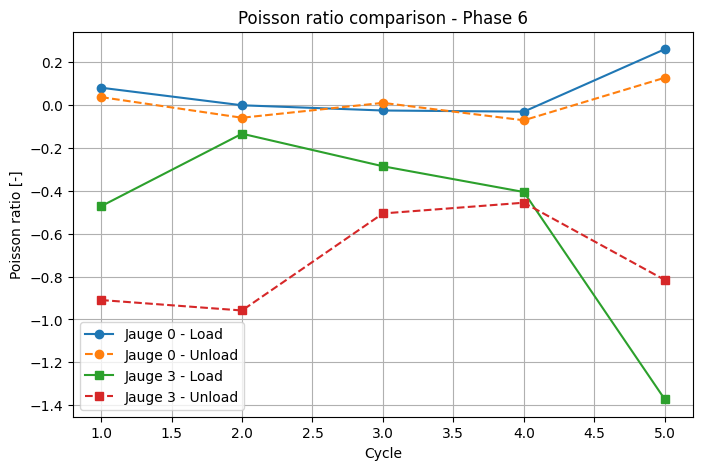

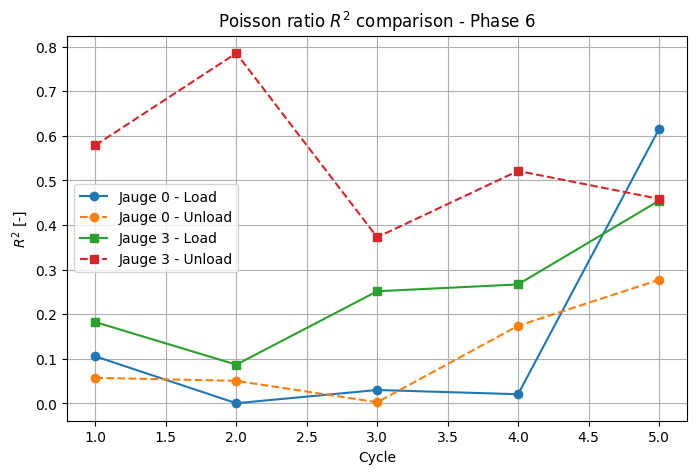

Poisson - Jauge 0: 0.216 - 0.039
Poisson - Jauge 3: -0.726 - -0.765


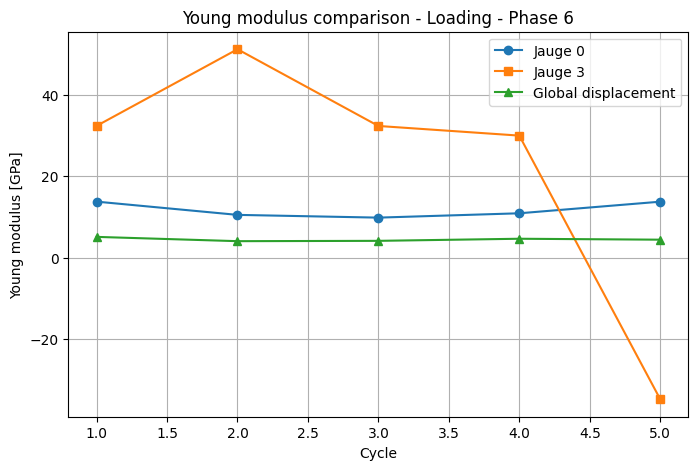

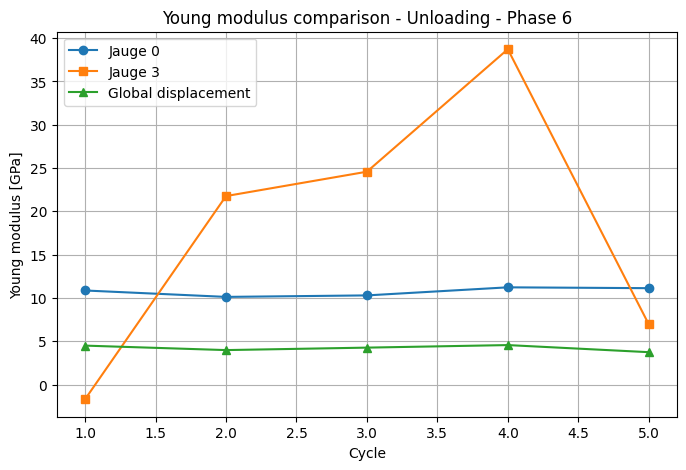

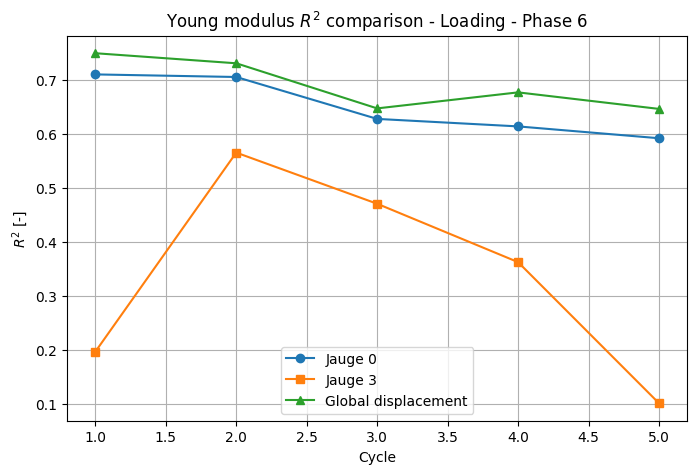

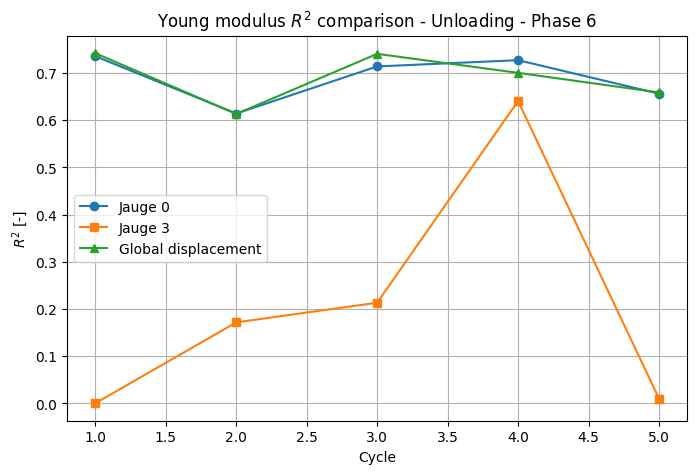

Young - Jauge 0 [GPa]: 11.75 - 10.74
Young - Jauge 3 [GPa]: 34.17 - 32.68
Young - Global [GPa]: 4.46 - 4.22


In [9]:
print('p6:', round(2/section_sample/1e3,2), 'MPa - small cycles')

# Times selected visually from the global time plot
t0 = 42800  # s
t1 = 44800  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p6, poisson_l_p6, strain_l_p6, R2_E_l_p6, R2_P_l_p6 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p6, poisson_u_p6, strain_u_p6, R2_E_u_p6, R2_P_u_p6 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p6, poisson_l_v3_p6, strain_l_v3_p6, R2_E_l_v3_p6, R2_P_l_v3_p6 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p6, poisson_u_v3_p6, strain_u_v3_p6, R2_E_u_v3_p6, R2_P_u_v3_p6 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p6, _, strain_l_global_p6, R2_E_l_global_p6, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p6, _, strain_u_global_p6, R2_E_u_global_p6, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p6) + 1),
    poisson_l_p6,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p6) + 1),
    poisson_u_p6,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p6) + 1),
    poisson_l_v3_p6,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p6) + 1),
    poisson_u_v3_p6,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 6')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p6) + 1),
    R2_P_l_p6,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p6) + 1),
    R2_P_u_p6,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p6) + 1),
    R2_P_l_v3_p6,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p6) + 1),
    R2_P_u_v3_p6,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 6')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p6, R2_P_l_p6), 3),
    '-',
    round(mean_R2(poisson_u_p6, R2_P_u_p6), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p6, R2_P_l_v3_p6), 3),
    '-',
    round(mean_R2(poisson_u_v3_p6, R2_P_u_v3_p6), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p6) + 1),
    np.asarray(E_l_p6) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p6) + 1),
    np.asarray(E_l_v3_p6) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p6) + 1),
    np.asarray(E_l_global_p6) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 6')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p6) + 1),
    np.asarray(E_u_p6) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p6) + 1),
    np.asarray(E_u_v3_p6) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p6) + 1),
    np.asarray(E_u_global_p6) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 6')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p6) + 1),
    R2_E_l_p6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p6) + 1),
    R2_E_l_v3_p6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p6) + 1),
    R2_E_l_global_p6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 6')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p6) + 1),
    R2_E_u_p6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p6) + 1),
    R2_E_u_v3_p6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p6) + 1),
    R2_E_u_global_p6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 6')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p6, R2_E_l_p6) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p6, R2_E_u_p6) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p6, R2_E_l_v3_p6) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p6, R2_E_u_v3_p6) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p6, R2_E_l_global_p6) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p6, R2_E_u_global_p6) / 1e6, 2)
)

p7: 1.8 MPa - big cycles
Requested time interval: 45000.00 s -> 55000.00 s
Nearest available times: 45000.46 s -> 55000.03 s
Corresponding row indices: 22418 -> 27380
Number of selected rows: 4963


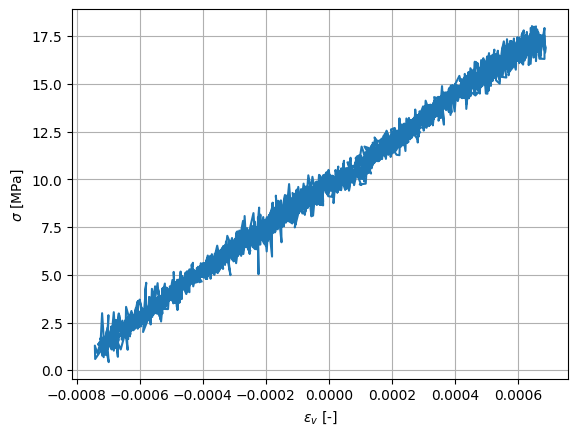

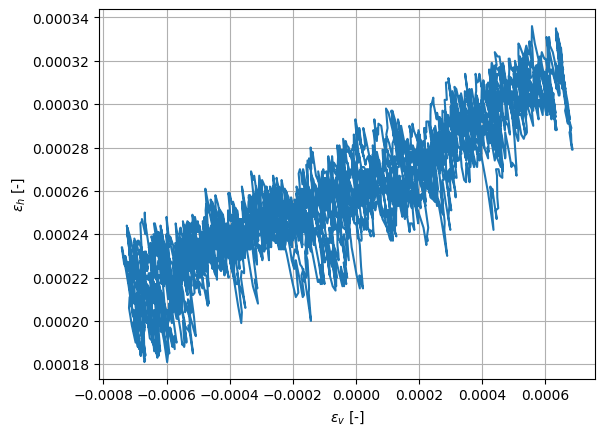

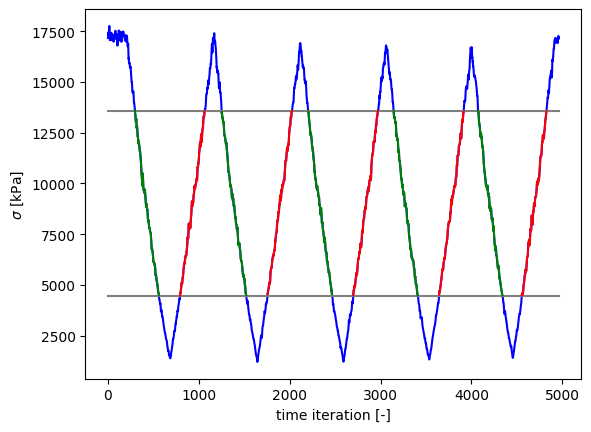

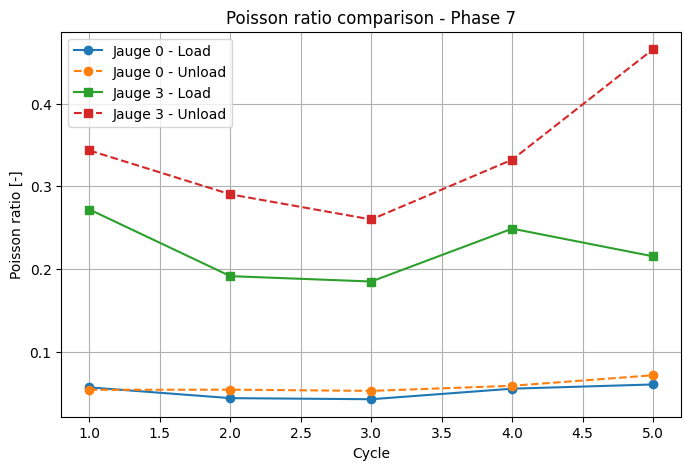

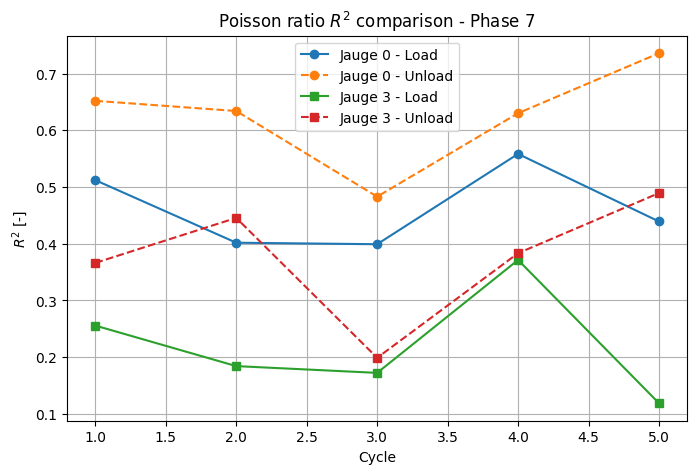

Poisson - Jauge 0: 0.052 - 0.059
Poisson - Jauge 3: 0.231 - 0.351


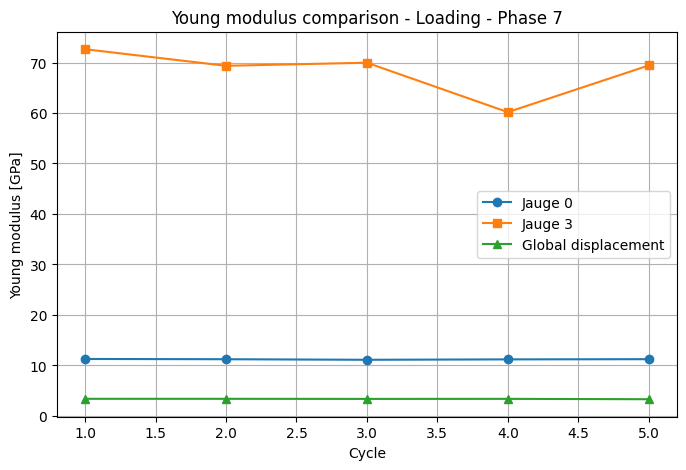

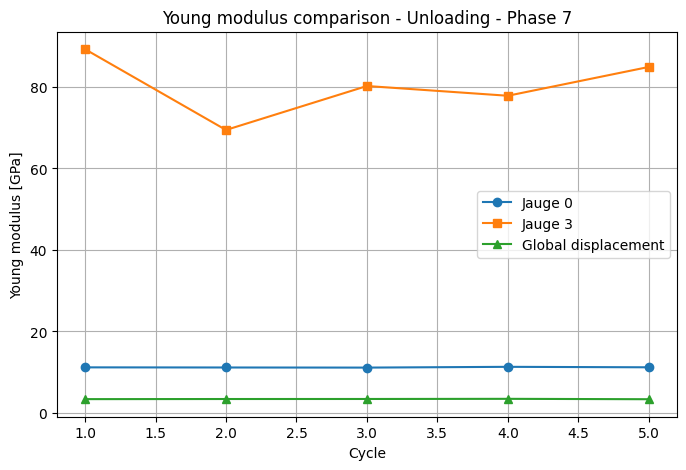

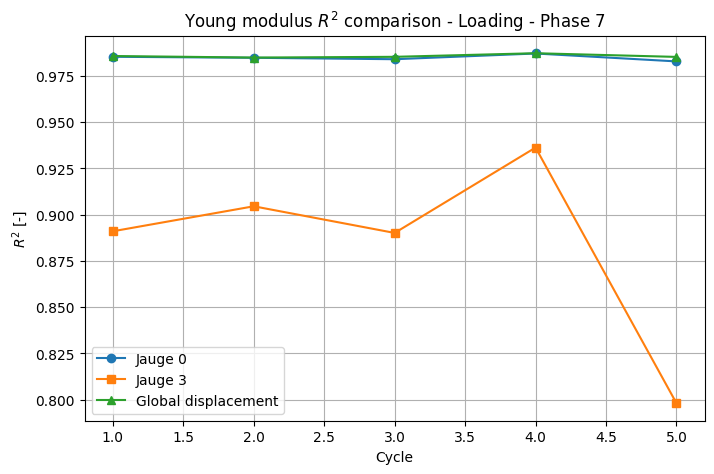

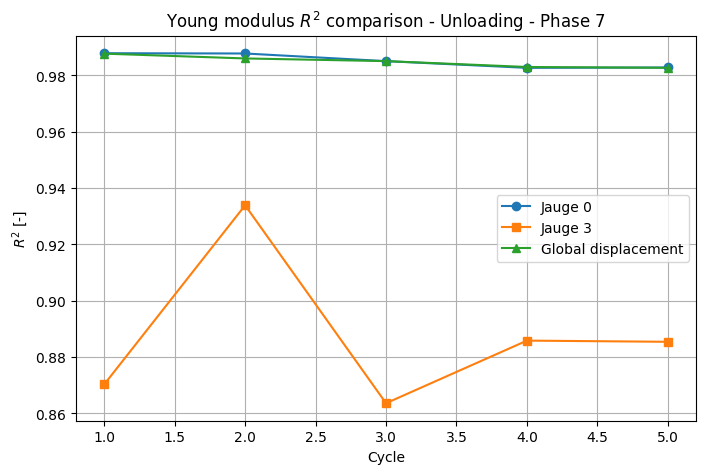

Young - Jauge 0 [GPa]: 11.21 - 11.19
Young - Jauge 3 [GPa]: 68.21 - 80.18
Young - Global [GPa]: 3.36 - 3.41


In [10]:
print('p7:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 45000  # s
t1 = 55000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p7, poisson_l_p7, strain_l_p7, R2_E_l_p7, R2_P_l_p7 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p7, poisson_u_p7, strain_u_p7, R2_E_u_p7, R2_P_u_p7 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p7, poisson_l_v3_p7, strain_l_v3_p7, R2_E_l_v3_p7, R2_P_l_v3_p7 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p7, poisson_u_v3_p7, strain_u_v3_p7, R2_E_u_v3_p7, R2_P_u_v3_p7 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p7, _, strain_l_global_p7, R2_E_l_global_p7, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p7, _, strain_u_global_p7, R2_E_u_global_p7, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p7) + 1),
    poisson_l_p7,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p7) + 1),
    poisson_u_p7,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p7) + 1),
    poisson_l_v3_p7,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p7) + 1),
    poisson_u_v3_p7,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 7')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p7) + 1),
    R2_P_l_p7,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p7) + 1),
    R2_P_u_p7,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p7) + 1),
    R2_P_l_v3_p7,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p7) + 1),
    R2_P_u_v3_p7,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 7')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p7, R2_P_l_p7), 3),
    '-',
    round(mean_R2(poisson_u_p7, R2_P_u_p7), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p7, R2_P_l_v3_p7), 3),
    '-',
    round(mean_R2(poisson_u_v3_p7, R2_P_u_v3_p7), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p7) + 1),
    np.asarray(E_l_p7) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p7) + 1),
    np.asarray(E_l_v3_p7) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p7) + 1),
    np.asarray(E_l_global_p7) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 7')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p7) + 1),
    np.asarray(E_u_p7) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p7) + 1),
    np.asarray(E_u_v3_p7) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p7) + 1),
    np.asarray(E_u_global_p7) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 7')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p7) + 1),
    R2_E_l_p7,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p7) + 1),
    R2_E_l_v3_p7,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p7) + 1),
    R2_E_l_global_p7,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 7')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p7) + 1),
    R2_E_u_p7,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p7) + 1),
    R2_E_u_v3_p7,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p7) + 1),
    R2_E_u_global_p7,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 7')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p7, R2_E_l_p7) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p7, R2_E_u_p7) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p7, R2_E_l_v3_p7) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p7, R2_E_u_v3_p7) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p7, R2_E_l_global_p7) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p7, R2_E_u_global_p7) / 1e6, 2)
)

p8: 1.8 MPa - medium cycles
Requested time interval: 55800.00 s -> 63000.00 s
Nearest available times: 55800.47 s -> 62999.08 s
Corresponding row indices: 27781 -> 31361
Number of selected rows: 3581


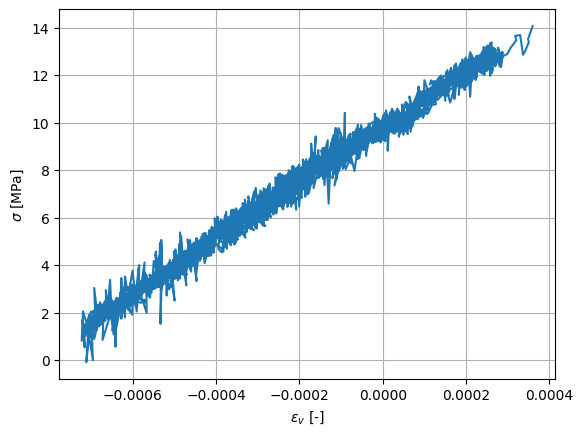

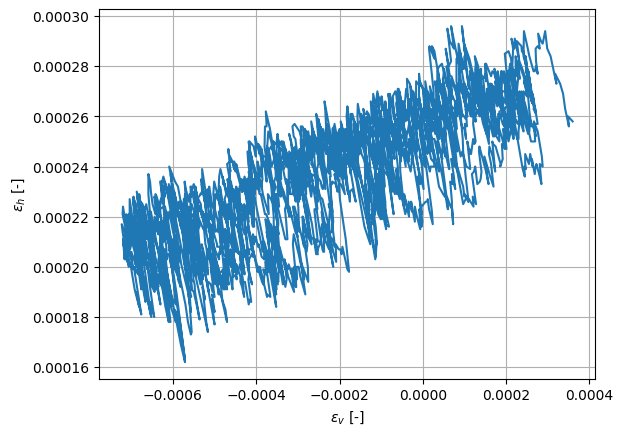

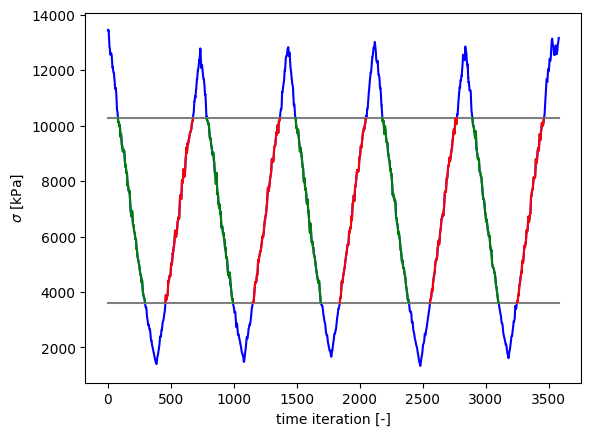

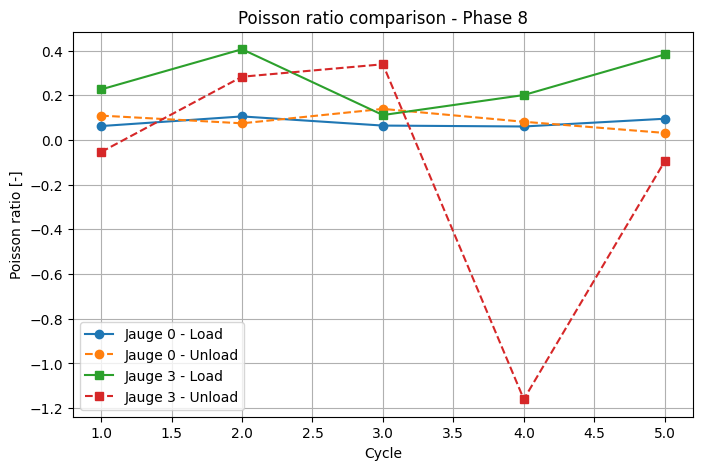

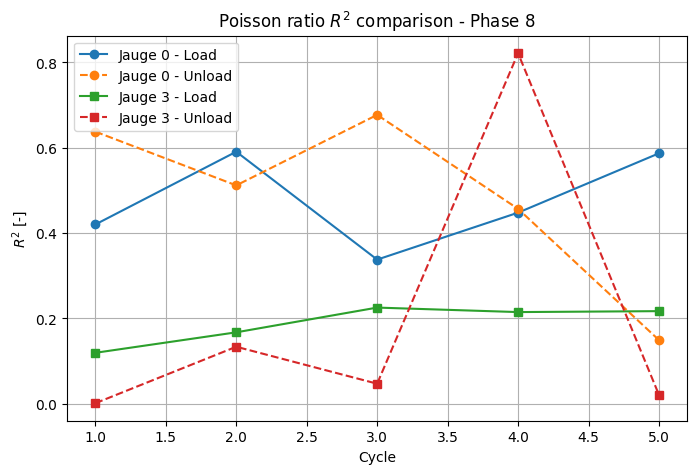

Poisson - Jauge 0: 0.081 - 0.1
Poisson - Jauge 3: 0.261 - -0.881


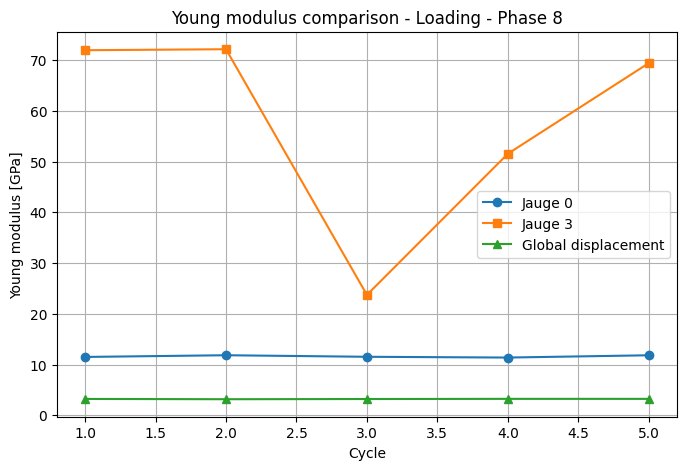

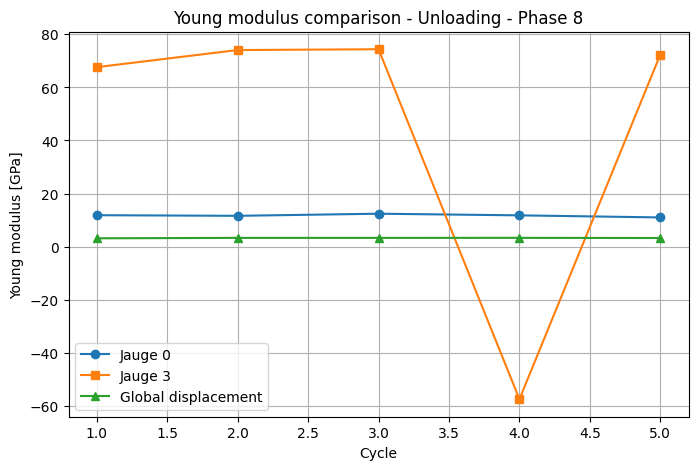

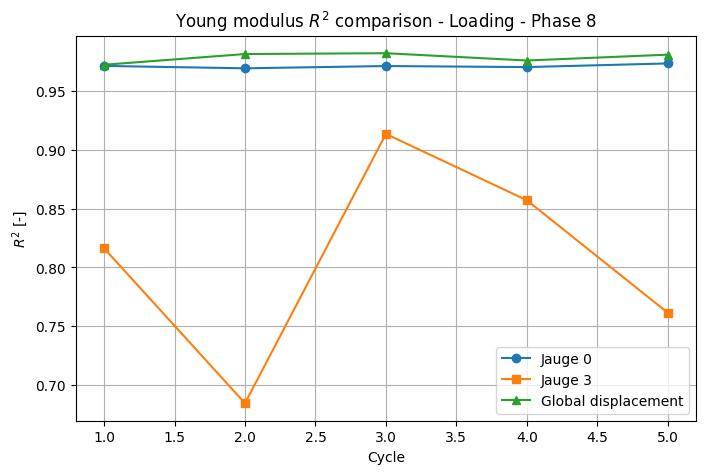

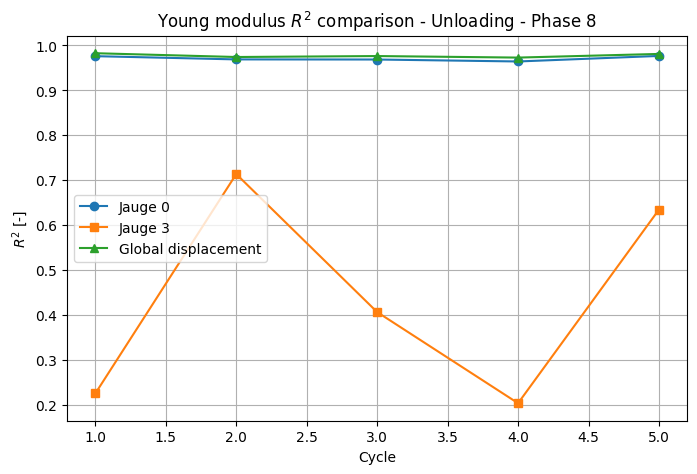

Young - Jauge 0 [GPa]: 11.62 - 11.72
Young - Jauge 3 [GPa]: 56.23 - 60.72
Young - Global [GPa]: 3.22 - 3.25


In [11]:
print('p8:', round(2/section_sample/1e3,2), 'MPa - medium cycles')

# Times selected visually from the global time plot
t0 = 55800  # s
t1 = 63000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p8, poisson_l_p8, strain_l_p8, R2_E_l_p8, R2_P_l_p8 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p8, poisson_u_p8, strain_u_p8, R2_E_u_p8, R2_P_u_p8 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p8, poisson_l_v3_p8, strain_l_v3_p8, R2_E_l_v3_p8, R2_P_l_v3_p8 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p8, poisson_u_v3_p8, strain_u_v3_p8, R2_E_u_v3_p8, R2_P_u_v3_p8 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p8, _, strain_l_global_p8, R2_E_l_global_p8, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p8, _, strain_u_global_p8, R2_E_u_global_p8, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p8) + 1),
    poisson_l_p8,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p8) + 1),
    poisson_u_p8,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p8) + 1),
    poisson_l_v3_p8,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p8) + 1),
    poisson_u_v3_p8,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 8')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p8) + 1),
    R2_P_l_p8,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p8) + 1),
    R2_P_u_p8,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p8) + 1),
    R2_P_l_v3_p8,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p8) + 1),
    R2_P_u_v3_p8,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 8')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p8, R2_P_l_p8), 3),
    '-',
    round(mean_R2(poisson_u_p8, R2_P_u_p8), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p8, R2_P_l_v3_p8), 3),
    '-',
    round(mean_R2(poisson_u_v3_p8, R2_P_u_v3_p8), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p8) + 1),
    np.asarray(E_l_p8) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p8) + 1),
    np.asarray(E_l_v3_p8) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p8) + 1),
    np.asarray(E_l_global_p8) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 8')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p8) + 1),
    np.asarray(E_u_p8) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p8) + 1),
    np.asarray(E_u_v3_p8) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p8) + 1),
    np.asarray(E_u_global_p8) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 8')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p8) + 1),
    R2_E_l_p8,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p8) + 1),
    R2_E_l_v3_p8,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p8) + 1),
    R2_E_l_global_p8,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 8')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p8) + 1),
    R2_E_u_p8,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p8) + 1),
    R2_E_u_v3_p8,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p8) + 1),
    R2_E_u_global_p8,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 8')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p8, R2_E_l_p8) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p8, R2_E_u_p8) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p8, R2_E_l_v3_p8) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p8, R2_E_u_v3_p8) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p8, R2_E_l_global_p8) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p8, R2_E_u_global_p8) / 1e6, 2)
)

p9: 1.8 MPa - big cycles
Requested time interval: 70000.00 s -> 83000.00 s
Nearest available times: 70000.00 s -> 83000.89 s
Corresponding row indices: 34856 -> 41308
Number of selected rows: 6453


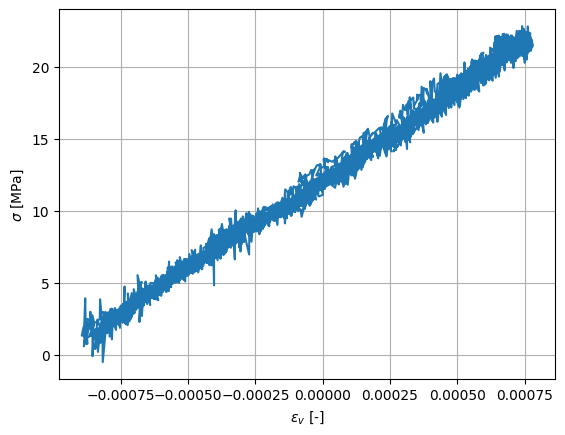

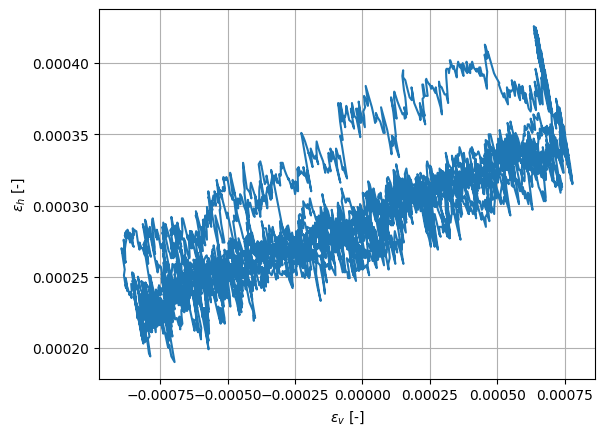

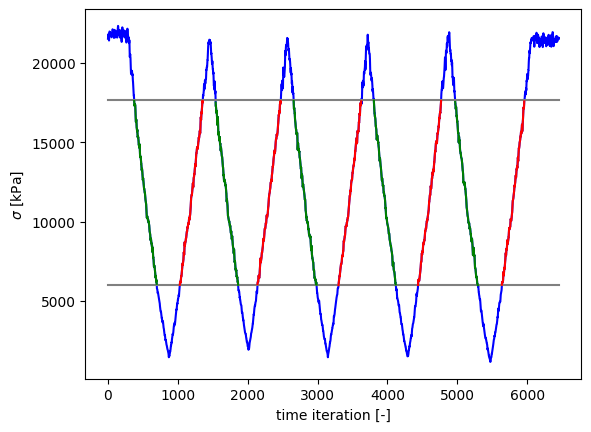

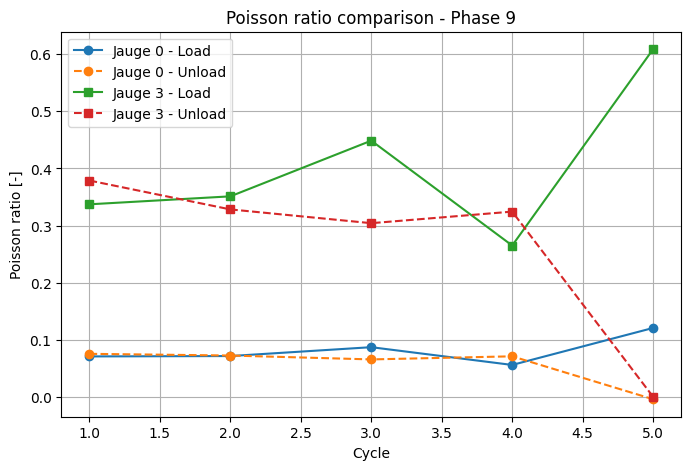

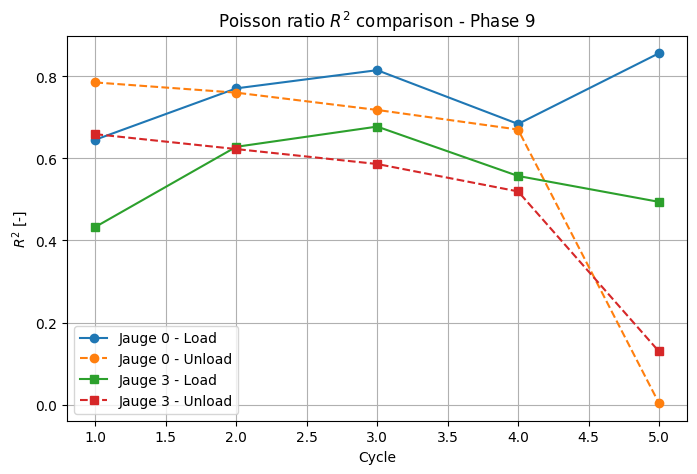

Poisson - Jauge 0: 0.084 - 0.072
Poisson - Jauge 3: 0.401 - 0.318


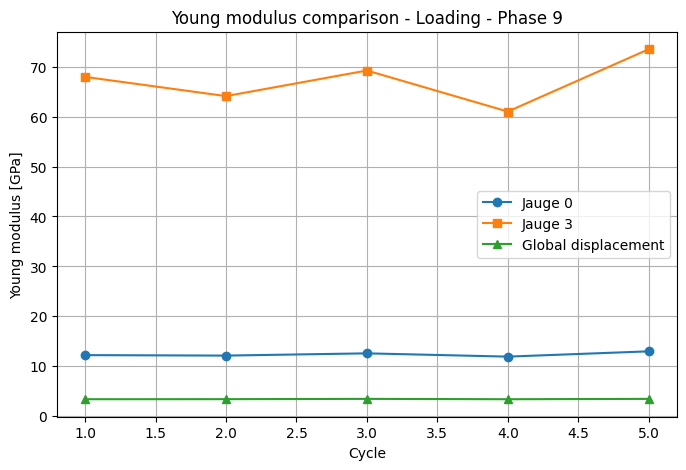

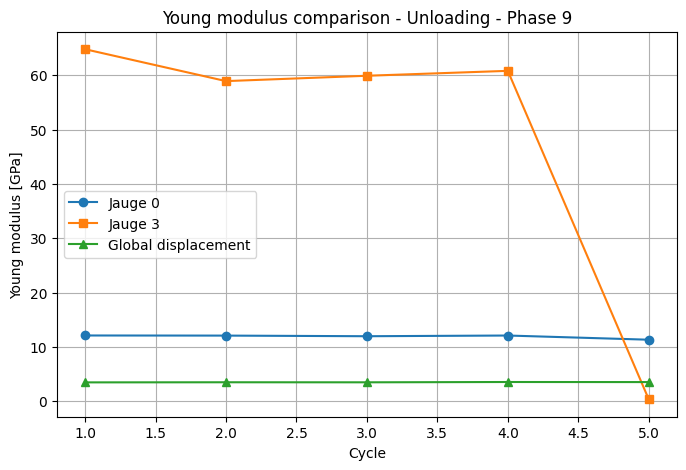

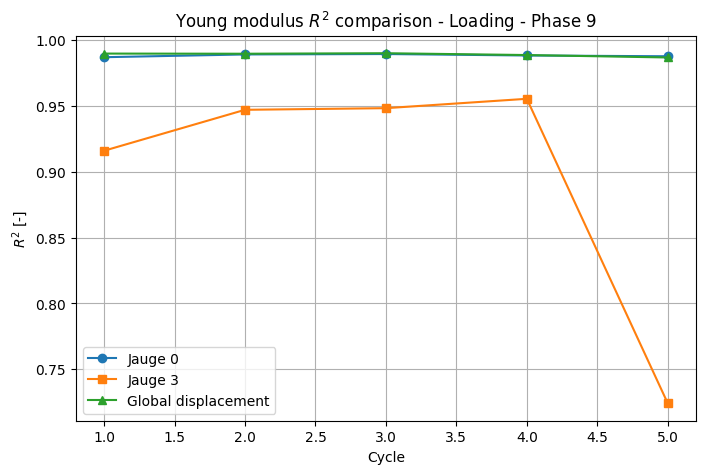

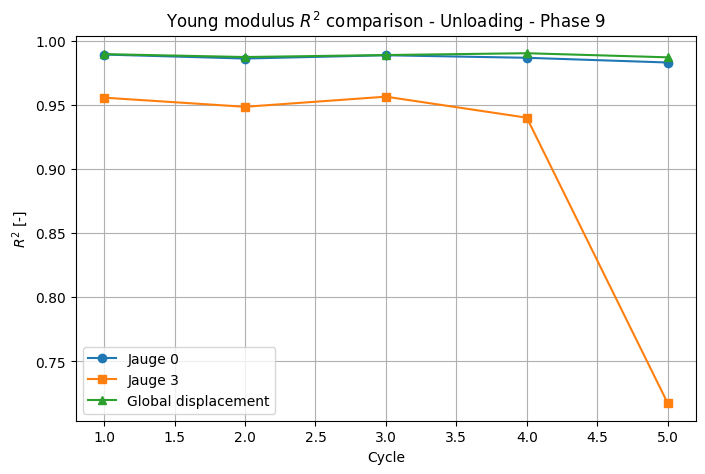

Young - Jauge 0 [GPa]: 12.37 - 11.91
Young - Jauge 3 [GPa]: 66.84 - 51.47
Young - Global [GPa]: 3.43 - 3.5


In [12]:
print('p9:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 70000  # s
t1 = 83000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p9, poisson_l_p9, strain_l_p9, R2_E_l_p9, R2_P_l_p9 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p9, poisson_u_p9, strain_u_p9, R2_E_u_p9, R2_P_u_p9 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p9, poisson_l_v3_p9, strain_l_v3_p9, R2_E_l_v3_p9, R2_P_l_v3_p9 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p9, poisson_u_v3_p9, strain_u_v3_p9, R2_E_u_v3_p9, R2_P_u_v3_p9 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p9, _, strain_l_global_p9, R2_E_l_global_p9, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p9, _, strain_u_global_p9, R2_E_u_global_p9, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p9) + 1),
    poisson_l_p9,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p9) + 1),
    poisson_u_p9,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p9) + 1),
    poisson_l_v3_p9,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p9) + 1),
    poisson_u_v3_p9,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 9')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p9) + 1),
    R2_P_l_p9,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p9) + 1),
    R2_P_u_p9,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p9) + 1),
    R2_P_l_v3_p9,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p9) + 1),
    R2_P_u_v3_p9,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 9')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p9, R2_P_l_p9), 3),
    '-',
    round(mean_R2(poisson_u_p9, R2_P_u_p9), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p9, R2_P_l_v3_p9), 3),
    '-',
    round(mean_R2(poisson_u_v3_p9, R2_P_u_v3_p9), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p9) + 1),
    np.asarray(E_l_p9) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p9) + 1),
    np.asarray(E_l_v3_p9) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p9) + 1),
    np.asarray(E_l_global_p9) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 9')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p9) + 1),
    np.asarray(E_u_p9) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p9) + 1),
    np.asarray(E_u_v3_p9) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p9) + 1),
    np.asarray(E_u_global_p9) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 9')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p9) + 1),
    R2_E_l_p9,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p9) + 1),
    R2_E_l_v3_p9,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p9) + 1),
    R2_E_l_global_p9,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 9')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p9) + 1),
    R2_E_u_p9,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p9) + 1),
    R2_E_u_v3_p9,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p9) + 1),
    R2_E_u_global_p9,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 9')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p9, R2_E_l_p9) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p9, R2_E_u_p9) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p9, R2_E_l_v3_p9) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p9, R2_E_u_v3_p9) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p9, R2_E_l_global_p9) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p9, R2_E_u_global_p9) / 1e6, 2)
)

p10: 1.8 MPa - medium cycles
Requested time interval: 87400.00 s -> 96000.00 s
Nearest available times: 87400.57 s -> 96000.17 s
Corresponding row indices: 43509 -> 47773
Number of selected rows: 4265


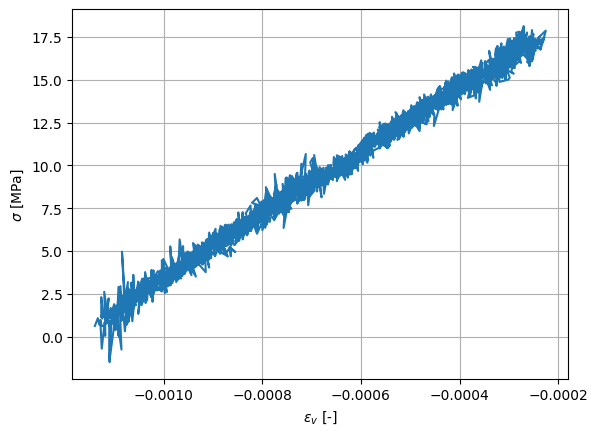

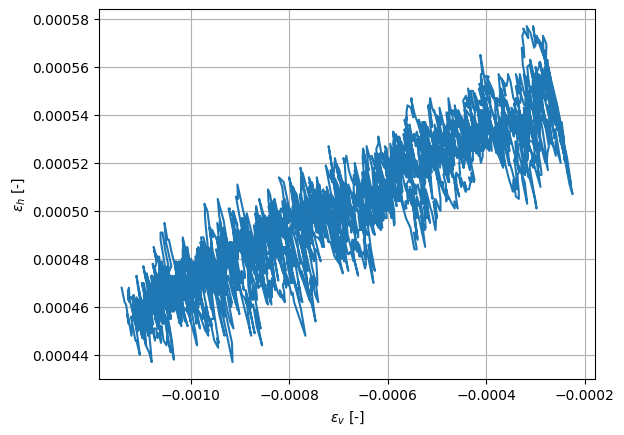

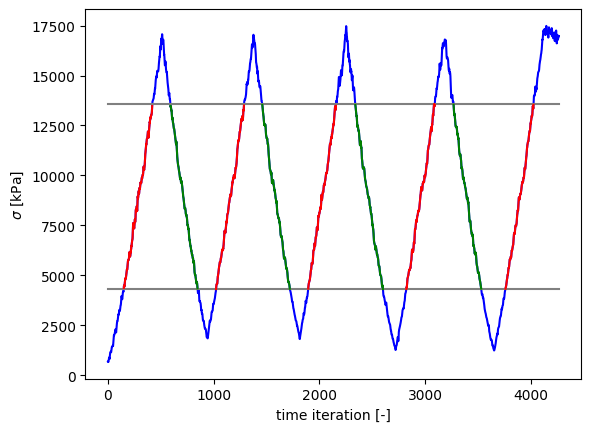

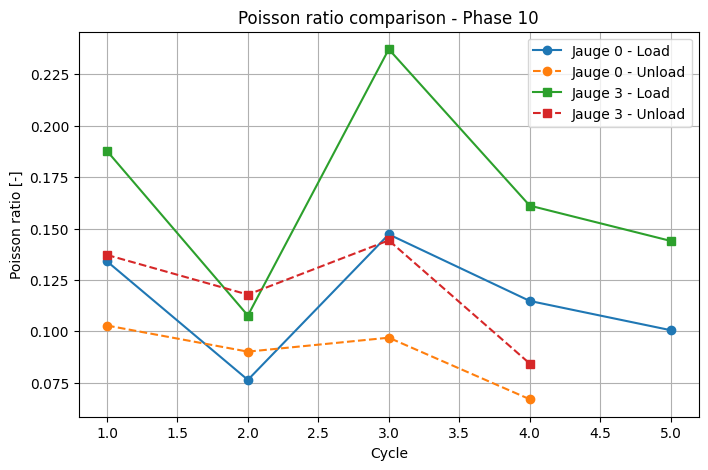

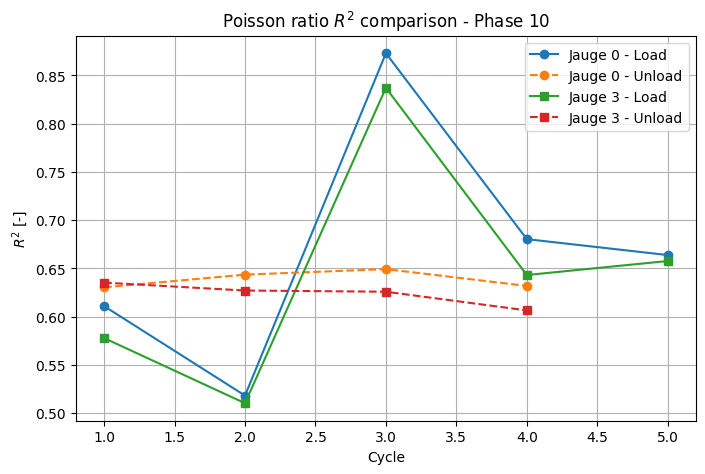

Poisson - Jauge 0: 0.118 - 0.089
Poisson - Jauge 3: 0.174 - 0.121


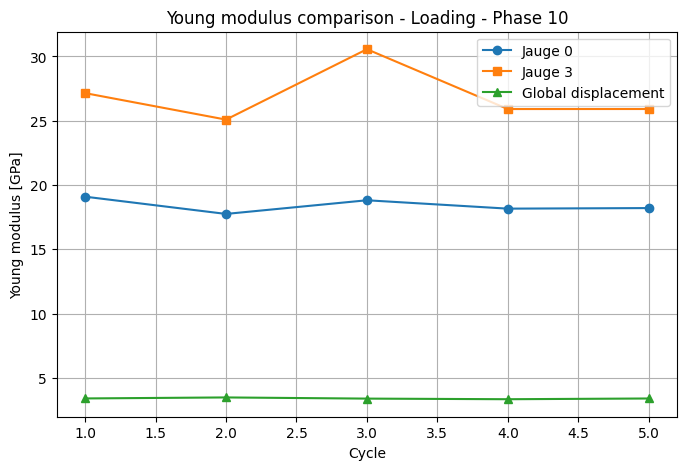

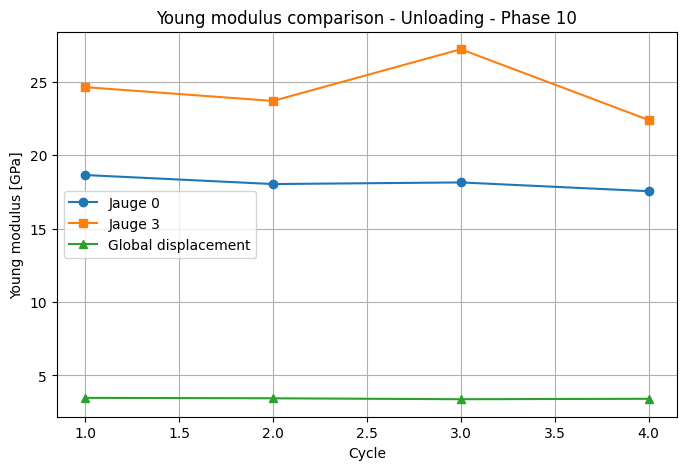

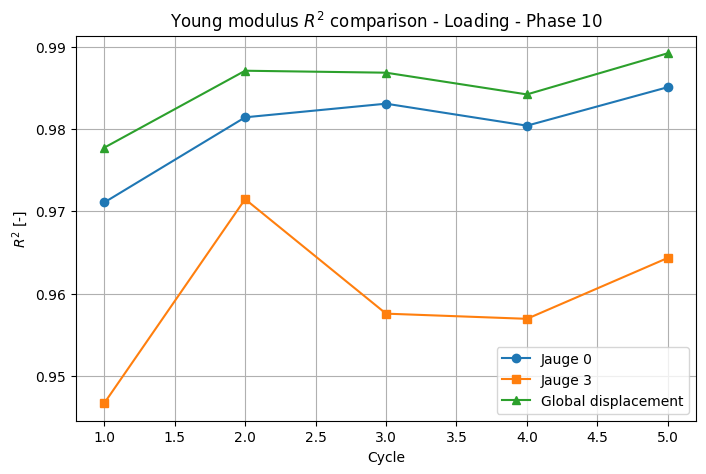

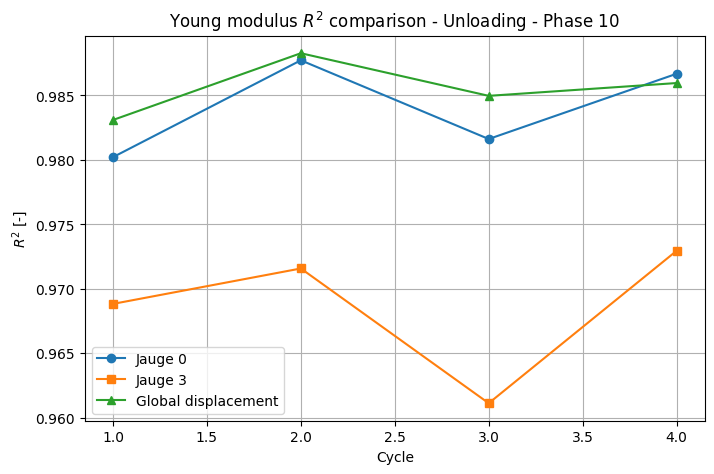

Young - Jauge 0 [GPa]: 18.41 - 18.09
Young - Jauge 3 [GPa]: 26.92 - 24.47
Young - Global [GPa]: 3.41 - 3.43


In [13]:
print('p10:', round(2/section_sample/1e3,2), 'MPa - medium cycles')

# Times selected visually from the global time plot
t0 = 87400  # s
t1 = 96000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p10, poisson_l_p10, strain_l_p10, R2_E_l_p10, R2_P_l_p10 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p10, poisson_u_p10, strain_u_p10, R2_E_u_p10, R2_P_u_p10 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p10, poisson_l_v3_p10, strain_l_v3_p10, R2_E_l_v3_p10, R2_P_l_v3_p10 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p10, poisson_u_v3_p10, strain_u_v3_p10, R2_E_u_v3_p10, R2_P_u_v3_p10 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p10, _, strain_l_global_p10, R2_E_l_global_p10, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p10, _, strain_u_global_p10, R2_E_u_global_p10, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p10) + 1),
    poisson_l_p10,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p10) + 1),
    poisson_u_p10,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p10) + 1),
    poisson_l_v3_p10,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p10) + 1),
    poisson_u_v3_p10,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p10) + 1),
    R2_P_l_p10,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p10) + 1),
    R2_P_u_p10,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p10) + 1),
    R2_P_l_v3_p10,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p10) + 1),
    R2_P_u_v3_p10,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 10')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p10, R2_P_l_p10), 3),
    '-',
    round(mean_R2(poisson_u_p10, R2_P_u_p10), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p10, R2_P_l_v3_p10), 3),
    '-',
    round(mean_R2(poisson_u_v3_p10, R2_P_u_v3_p10), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p10) + 1),
    np.asarray(E_l_p10) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p10) + 1),
    np.asarray(E_l_v3_p10) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p10) + 1),
    np.asarray(E_l_global_p10) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p10) + 1),
    np.asarray(E_u_p10) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p10) + 1),
    np.asarray(E_u_v3_p10) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p10) + 1),
    np.asarray(E_u_global_p10) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p10) + 1),
    R2_E_l_p10,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p10) + 1),
    R2_E_l_v3_p10,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p10) + 1),
    R2_E_l_global_p10,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p10) + 1),
    R2_E_u_p10,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p10) + 1),
    R2_E_u_v3_p10,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p10) + 1),
    R2_E_u_global_p10,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 10')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p10, R2_E_l_p10) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p10, R2_E_u_p10) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p10, R2_E_l_v3_p10) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p10, R2_E_u_v3_p10) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p10, R2_E_l_global_p10) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p10, R2_E_u_global_p10) / 1e6, 2)
)

p11: 1.8 MPa - big cycles
Requested time interval: 108000.00 s -> 121000.00 s
Nearest available times: 108000.91 s -> 120999.61 s
Corresponding row indices: 53771 -> 60227
Number of selected rows: 6457


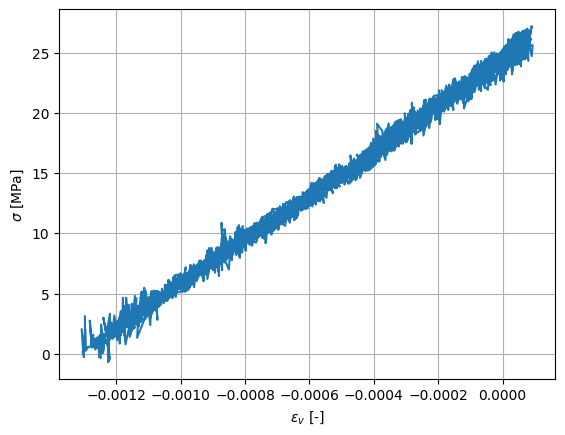

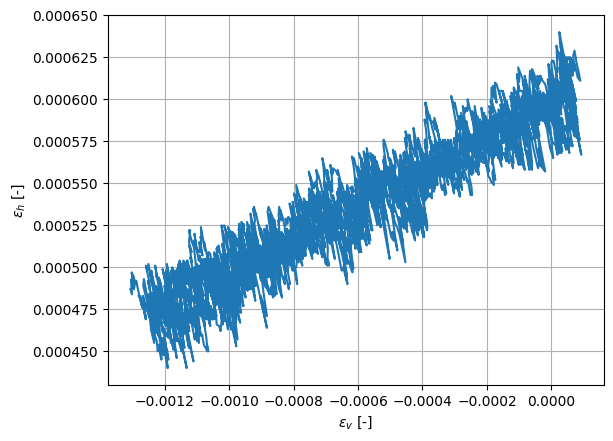

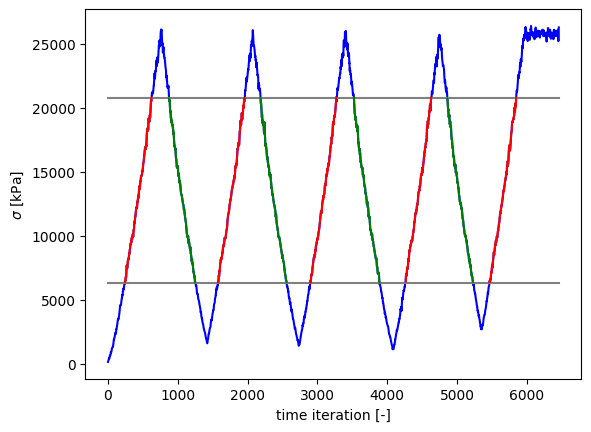

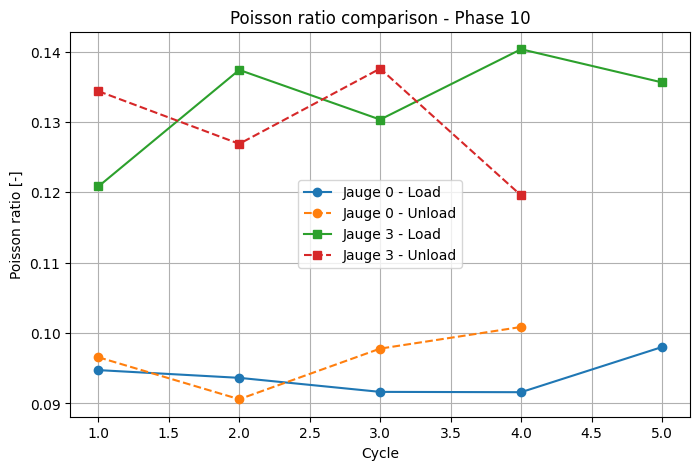

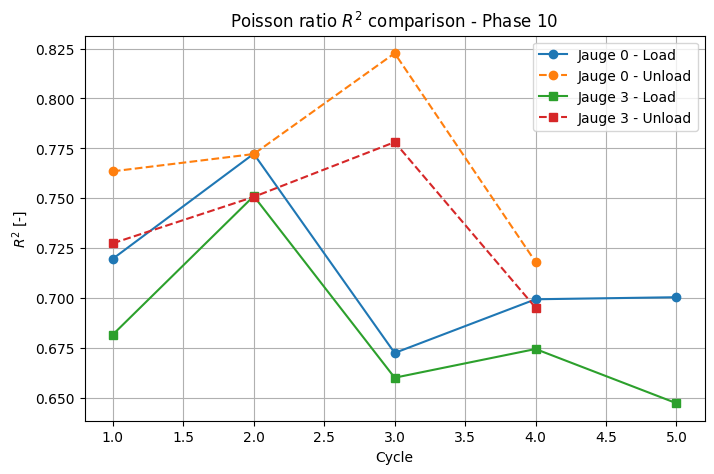

Poisson - Jauge 0: 0.094 - 0.096
Poisson - Jauge 3: 0.133 - 0.13


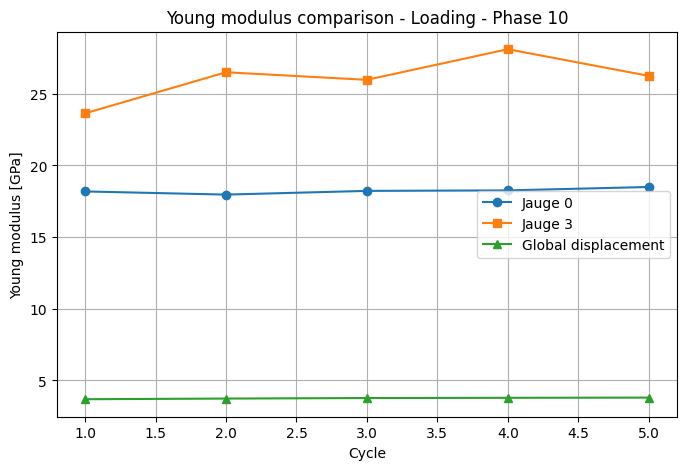

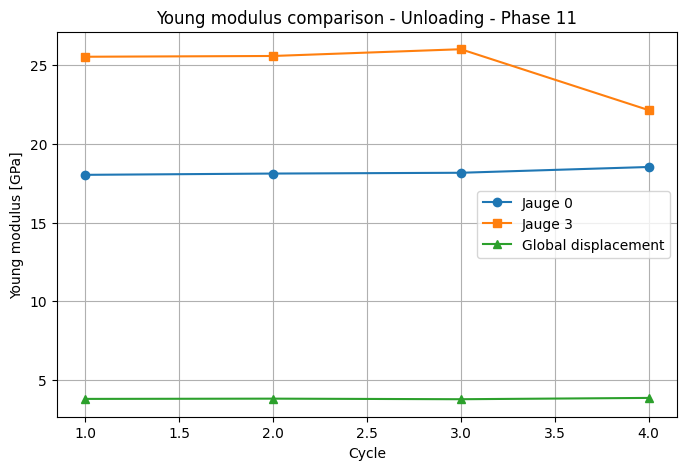

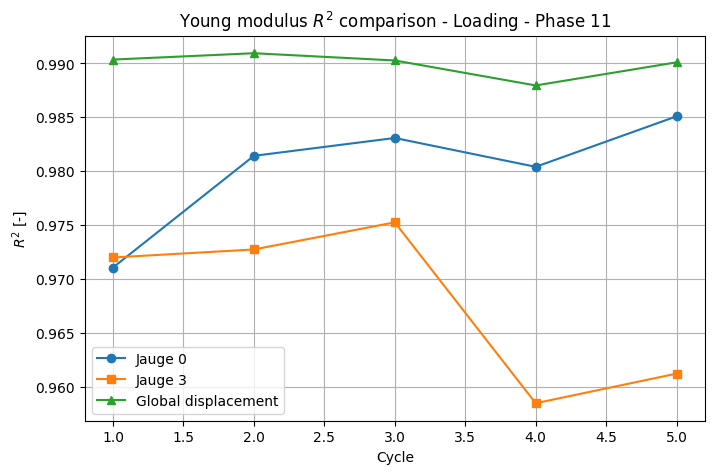

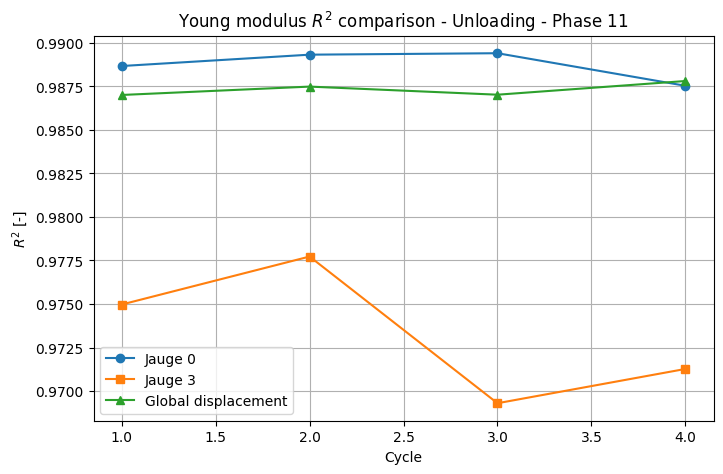

Young - Jauge 0 [GPa]: 18.23 - 18.21
Young - Jauge 3 [GPa]: 26.09 - 24.82
Young - Global [GPa]: 3.75 - 3.82


In [14]:
print('p11:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 108000  # s
t1 = 121000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p11, poisson_l_p11, strain_l_p11, R2_E_l_p11, R2_P_l_p11 = loading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load)
E_u_p11, poisson_u_p11, strain_u_p11, R2_E_u_p11, R2_P_u_p11 = unloading(eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p11, poisson_l_v3_p11, strain_l_v3_p11, R2_E_l_v3_p11, R2_P_l_v3_p11 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p11, poisson_u_v3_p11, strain_u_v3_p11, R2_E_u_v3_p11, R2_P_u_v3_p11 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p11, _, strain_l_global_p11, R2_E_l_global_p11, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p11, _, strain_u_global_p11, R2_E_u_global_p11, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")
# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)
# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='r')
for iters in L_iters_cycle_unload:
    plt.plot(range(iters[0], iters[1]+1), stress_pp_filter[iters[0]: iters[1]+1], color='g')
# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()

# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p11) + 1),
    poisson_l_p11,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p11) + 1),
    poisson_u_p11,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p11) + 1),
    poisson_l_v3_p11,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p11) + 1),
    poisson_u_v3_p11,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p11) + 1),
    R2_P_l_p11,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p11) + 1),
    R2_P_u_p11,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p11) + 1),
    R2_P_l_v3_p11,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p11) + 1),
    R2_P_u_v3_p11,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 10')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p11, R2_P_l_p11), 3),
    '-',
    round(mean_R2(poisson_u_p11, R2_P_u_p11), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p11, R2_P_l_v3_p11), 3),
    '-',
    round(mean_R2(poisson_u_v3_p11, R2_P_u_v3_p11), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p11) + 1),
    np.asarray(E_l_p11) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p11) + 1),
    np.asarray(E_l_v3_p11) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p11) + 1),
    np.asarray(E_l_global_p11) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 10')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p11) + 1),
    np.asarray(E_u_p11) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p11) + 1),
    np.asarray(E_u_v3_p11) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p11) + 1),
    np.asarray(E_u_global_p11) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 11')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p10) + 1),
    R2_E_l_p10,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p11) + 1),
    R2_E_l_v3_p11,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p11) + 1),
    R2_E_l_global_p11,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 11')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p11) + 1),
    R2_E_u_p11,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p11) + 1),
    R2_E_u_v3_p11,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p11) + 1),
    R2_E_u_global_p11,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 11')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p11, R2_E_l_p11) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p11, R2_E_u_p11) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p11, R2_E_l_v3_p11) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p11, R2_E_u_v3_p11) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p11, R2_E_l_global_p11) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p11, R2_E_u_global_p11) / 1e6, 2)
)

p12: 1.8 MPa - medium cycles
Requested time interval: 122500.00 s -> 134000.00 s
Nearest available times: 122500.12 s -> 133999.83 s
Corresponding row indices: 60978 -> 66685
Number of selected rows: 5708


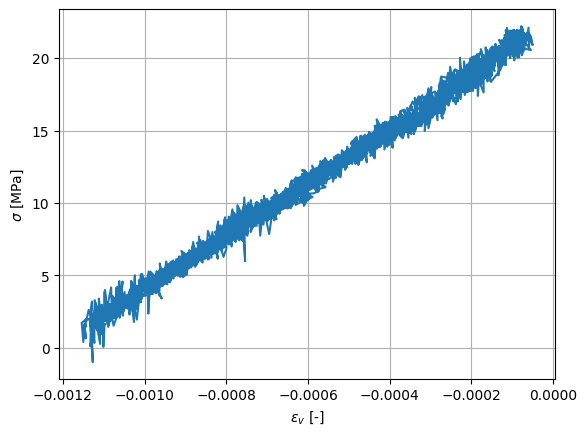

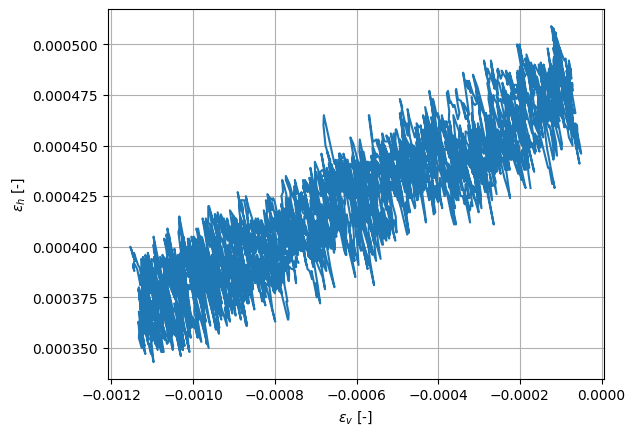

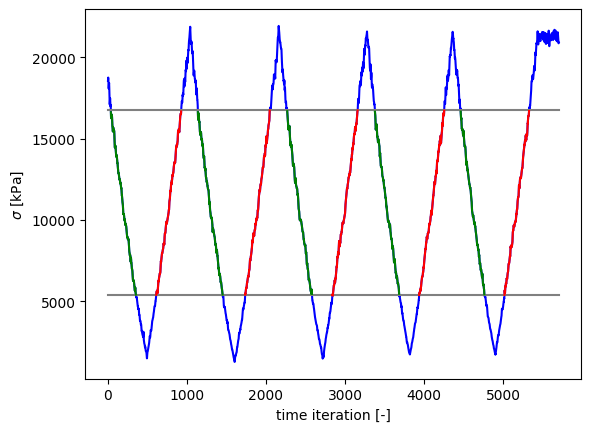

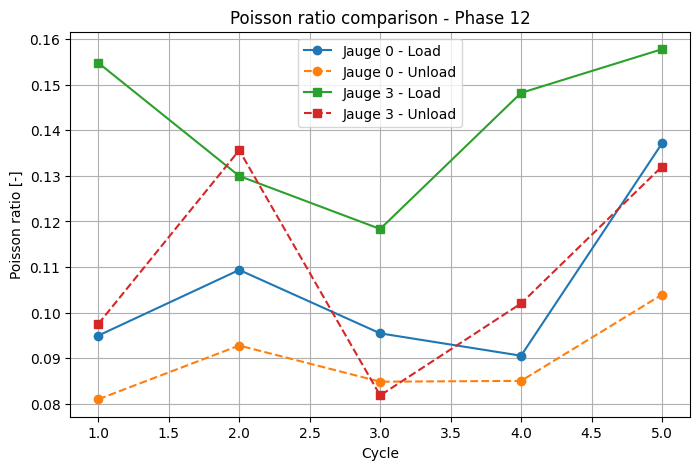

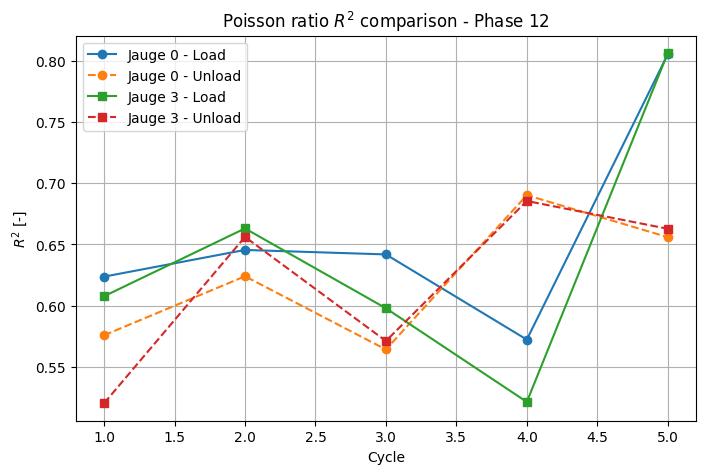

Poisson - Jauge 0: 0.107 - 0.09
Poisson - Jauge 3: 0.142 - 0.111


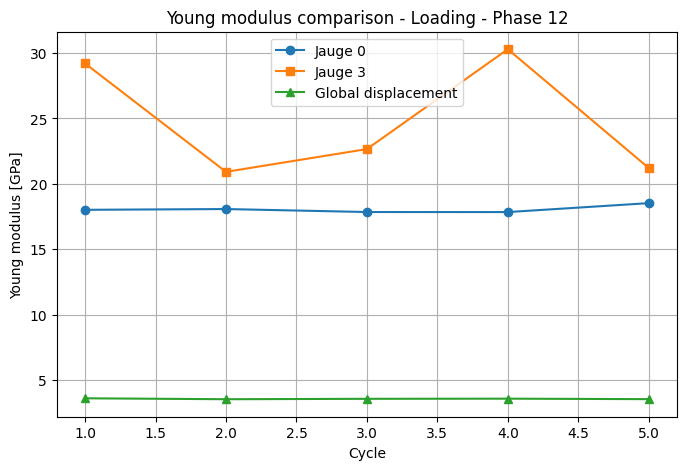

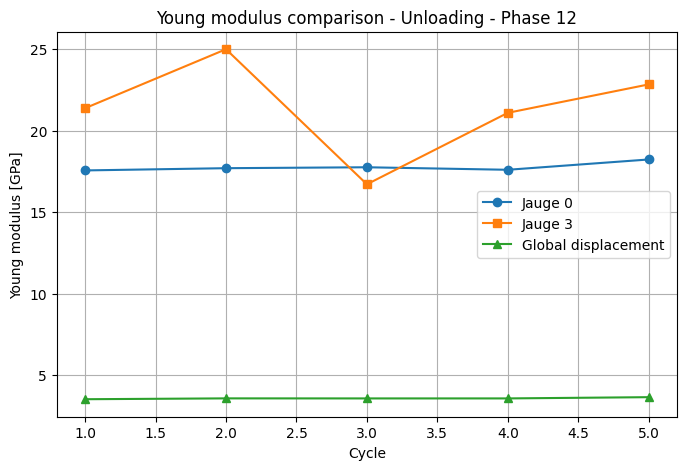

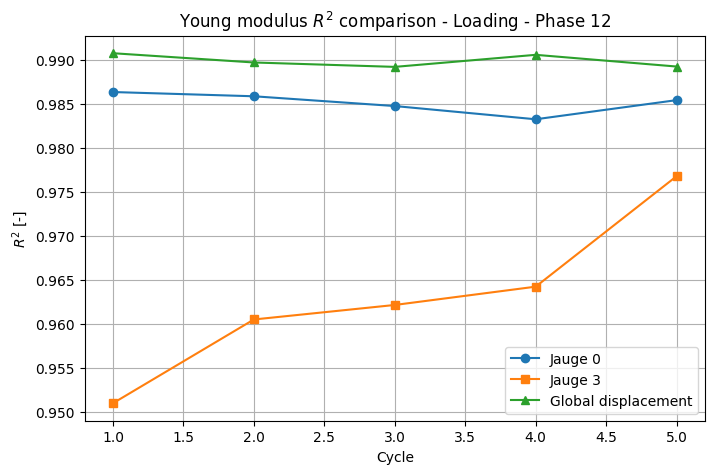

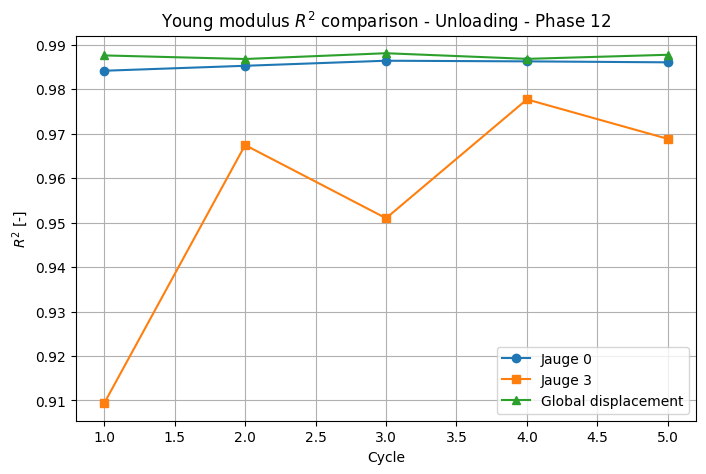

Young - Jauge 0 [GPa]: 18.06 - 17.76
Young - Jauge 3 [GPa]: 24.84 - 21.41
Young - Global [GPa]: 3.57 - 3.58


In [15]:
print('p12:', round(2/section_sample/1e3,2), 'MPa - medium cycles')

# Times selected visually from the global time plot
t0 = 122500  # s
t1 = 134000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p12, poisson_l_p12, strain_l_p12, R2_E_l_p12, R2_P_l_p12 = loading(
    eps_v_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_p12, poisson_u_p12, strain_u_p12, R2_E_u_p12, R2_P_u_p12 = unloading(
    eps_v_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p12, poisson_l_v3_p12, strain_l_v3_p12, R2_E_l_v3_p12, R2_P_l_v3_p12 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p12, poisson_u_v3_p12, strain_u_v3_p12, R2_E_u_v3_p12, R2_P_u_v3_p12 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p12, _, strain_l_global_p12, R2_E_l_global_p12, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p12, _, strain_u_global_p12, R2_E_u_global_p12, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")

# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)

# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]: iters[1]+1],
        color='r'
    )

for iters in L_iters_cycle_unload:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]: iters[1]+1],
        color='g'
    )

# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()


# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p12) + 1),
    poisson_l_p12,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p12) + 1),
    poisson_u_p12,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p12) + 1),
    poisson_l_v3_p12,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p12) + 1),
    poisson_u_v3_p12,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 12')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p12) + 1),
    R2_P_l_p12,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p12) + 1),
    R2_P_u_p12,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p12) + 1),
    R2_P_l_v3_p12,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p12) + 1),
    R2_P_u_v3_p12,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 12')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p12, R2_P_l_p12), 3),
    '-',
    round(mean_R2(poisson_u_p12, R2_P_u_p12), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p12, R2_P_l_v3_p12), 3),
    '-',
    round(mean_R2(poisson_u_v3_p12, R2_P_u_v3_p12), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p12) + 1),
    np.asarray(E_l_p12) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p12) + 1),
    np.asarray(E_l_v3_p12) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p12) + 1),
    np.asarray(E_l_global_p12) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 12')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p12) + 1),
    np.asarray(E_u_p12) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p12) + 1),
    np.asarray(E_u_v3_p12) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p12) + 1),
    np.asarray(E_u_global_p12) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 12')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p12) + 1),
    R2_E_l_p12,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p12) + 1),
    R2_E_l_v3_p12,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p12) + 1),
    R2_E_l_global_p12,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 12')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p12) + 1),
    R2_E_u_p12,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p12) + 1),
    R2_E_u_v3_p12,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p12) + 1),
    R2_E_u_global_p12,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 12')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p12, R2_E_l_p12) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p12, R2_E_u_p12) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p12, R2_E_l_v3_p12) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p12, R2_E_u_v3_p12) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p12, R2_E_l_global_p12) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p12, R2_E_u_global_p12) / 1e6, 2)
)

p13: 1.8 MPa - big cycles
Requested time interval: 143000.00 s -> 158500.00 s
Nearest available times: 143000.12 s -> 158498.95 s
Corresponding row indices: 71174 -> 78852
Number of selected rows: 7679


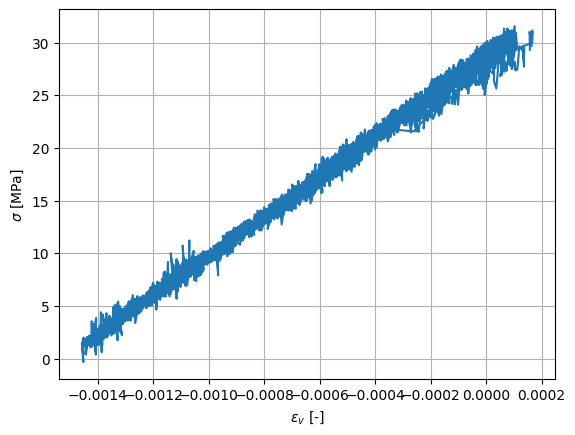

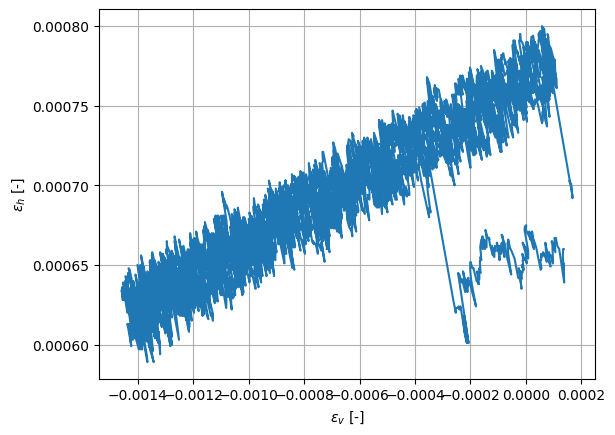

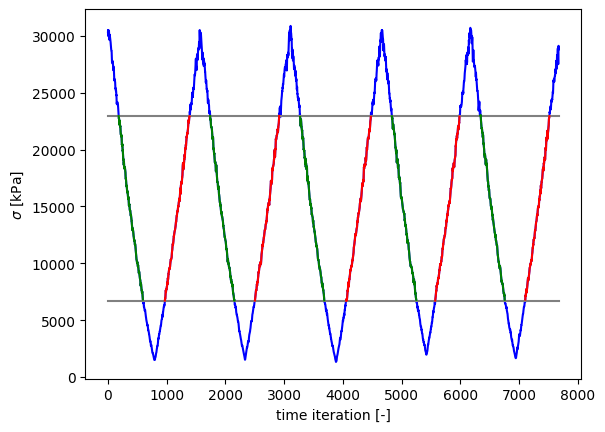

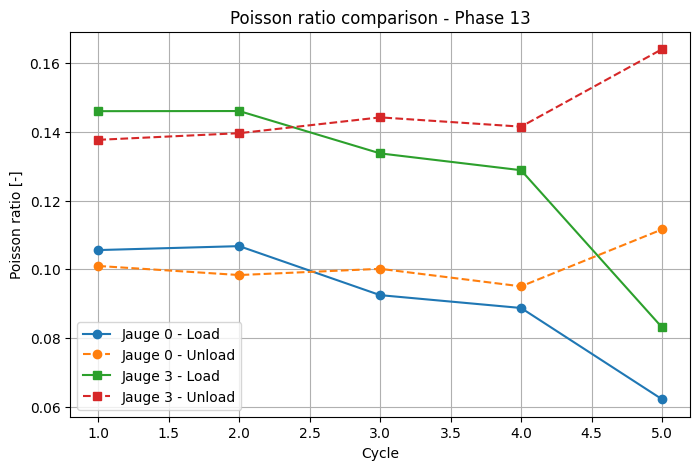

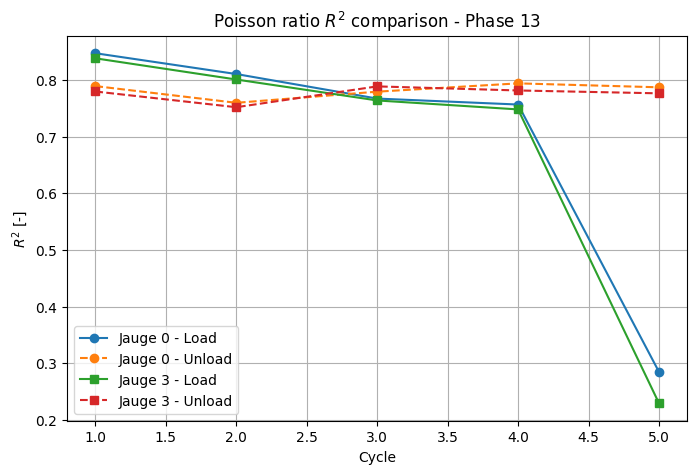

Poisson - Jauge 0: 0.096 - 0.101
Poisson - Jauge 3: 0.135 - 0.145


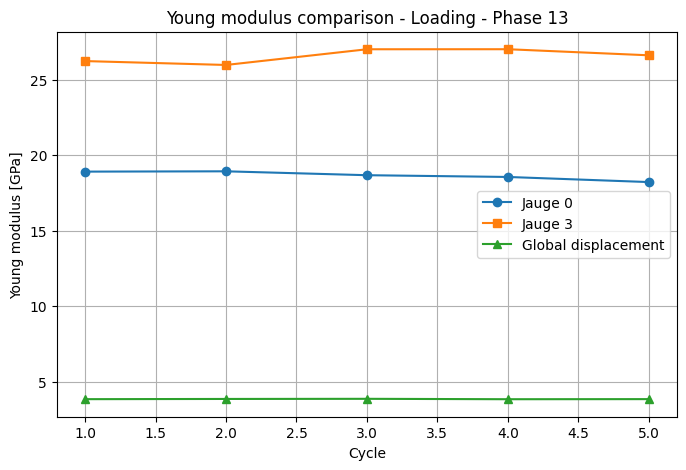

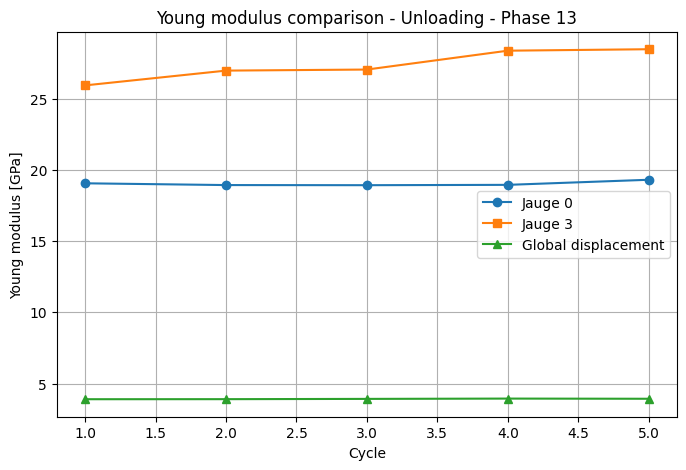

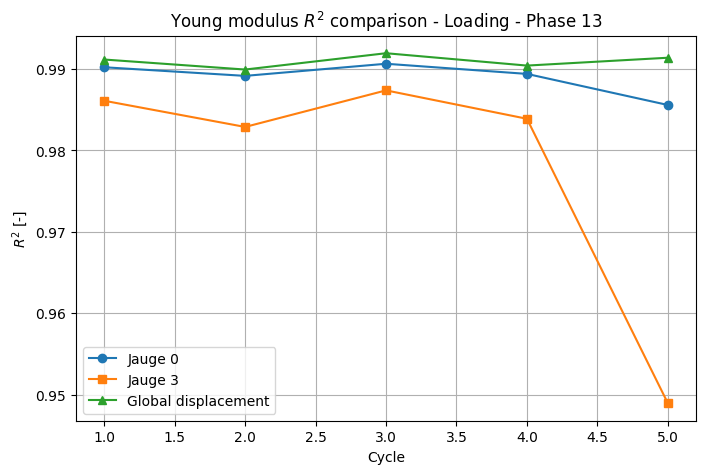

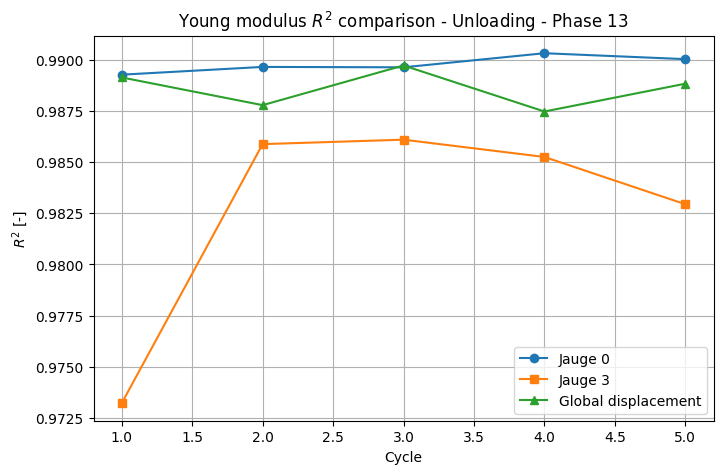

Young - Jauge 0 [GPa]: 18.66 - 19.03
Young - Jauge 3 [GPa]: 26.57 - 27.35
Young - Global [GPa]: 3.85 - 3.92


In [23]:
print('p13:', round(2/section_sample/1e3,2), 'MPa - big cycles')

# Times selected visually from the global time plot
t0 = 143000  # s
t1 = 158500  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

# Primero se eliminan los picos aislados con la mediana.
# Después se suavizan los escalones con una media móvil.
stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .median()
    .rolling(
        window=5,
        center=True,
        min_periods=1
    )
    .mean()
    .to_numpy()
)

# La detección se hace sobre la señal suavizada
L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p13, poisson_l_p13, strain_l_p13, R2_E_l_p13, R2_P_l_p13 = loading(
    eps_v_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_p13, poisson_u_p13, strain_u_p13, R2_E_u_p13, R2_P_u_p13 = unloading(
    eps_v_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Résultats avec la déformation verticale locale de Jauge 3
E_l_v3_p13, poisson_l_v3_p13, strain_l_v3_p13, R2_E_l_v3_p13, R2_P_l_v3_p13 = loading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_v3_p13, poisson_u_v3_p13, strain_u_v3_p13, R2_E_u_v3_p13, R2_P_u_v3_p13 = unloading(
    eps_v1_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# Module de Young avec la déformation verticale globale
E_l_global_p13, _, strain_l_global_p13, R2_E_l_global_p13, _ = loading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_load
)

E_u_global_p13, _, strain_u_global_p13, R2_E_u_global_p13, _ = unloading(
    eps_vglobal_pp,
    eps_h_pp,
    stress_pp,
    L_iters_cycle_unload
)

# plot the load pattern
plt.plot(eps_v[x0: x1], stress[x0: x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the load pattern
plt.plot(eps_v[x0: x1], eps_h[x0: x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

# plot the stress
plt.plot(stress_pp_filter, color="b")

# Limits of the box calculated with the filtered stress
mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = (
    mean_stress_filter
    - 0.55 * half_amplitude_filter
)

upper_limit = (
    mean_stress_filter
    + 0.55 * half_amplitude_filter
)

# Plot the two grey limits
plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)

# plot the cycles detection
for iters in L_iters_cycle_load:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]: iters[1]+1],
        color='r'
    )

for iters in L_iters_cycle_unload:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]: iters[1]+1],
        color='g'
    )

# close the plot
plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()


# =========================================================
# Comparaison du coefficient de Poisson
# Jauge 0 et Jauge 3
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(poisson_l_p13) + 1),
    poisson_l_p13,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_p13) + 1),
    poisson_u_p13,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(poisson_l_v3_p13) + 1),
    poisson_l_v3_p13,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(poisson_u_v3_p13) + 1),
    poisson_u_v3_p13,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 13')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du coefficient de Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_P_l_p13) + 1),
    R2_P_l_p13,
    marker='o',
    linestyle='-',
    label='Jauge 0 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_p13) + 1),
    R2_P_u_p13,
    marker='o',
    linestyle='--',
    label='Jauge 0 - Unload'
)

plt.plot(
    np.arange(1, len(R2_P_l_v3_p13) + 1),
    R2_P_l_v3_p13,
    marker='s',
    linestyle='-',
    label='Jauge 3 - Load'
)

plt.plot(
    np.arange(1, len(R2_P_u_v3_p13) + 1),
    R2_P_u_v3_p13,
    marker='s',
    linestyle='--',
    label='Jauge 3 - Unload'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 13')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p13, R2_P_l_p13), 3),
    '-',
    round(mean_R2(poisson_u_p13, R2_P_u_p13), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p13, R2_P_l_v3_p13), 3),
    '-',
    round(mean_R2(poisson_u_v3_p13, R2_P_u_v3_p13), 3)
)


# =========================================================
# Comparaison du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_l_p13) + 1),
    np.asarray(E_l_p13) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_l_v3_p13) + 1),
    np.asarray(E_l_v3_p13) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_l_global_p13) + 1),
    np.asarray(E_l_global_p13) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 13')
plt.legend()
plt.show()


# =========================================================
# Comparaison du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(E_u_p13) + 1),
    np.asarray(E_u_p13) / 1e6,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(E_u_v3_p13) + 1),
    np.asarray(E_u_v3_p13) / 1e6,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(E_u_global_p13) + 1),
    np.asarray(E_u_global_p13) / 1e6,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 13')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_l_p13) + 1),
    R2_E_l_p13,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_l_v3_p13) + 1),
    R2_E_l_v3_p13,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_l_global_p13) + 1),
    R2_E_l_global_p13,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 13')
plt.legend()
plt.show()


# =========================================================
# Comparaison des R² du module de Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(R2_E_u_p13) + 1),
    R2_E_u_p13,
    marker='o',
    label='Jauge 0'
)

plt.plot(
    np.arange(1, len(R2_E_u_v3_p13) + 1),
    R2_E_u_v3_p13,
    marker='s',
    label='Jauge 3'
)

plt.plot(
    np.arange(1, len(R2_E_u_global_p13) + 1),
    R2_E_u_global_p13,
    marker='^',
    label='Global displacement'
)

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 13')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p13, R2_E_l_p13) / 1e6, 2),
    '-',
    round(mean_R2(E_u_p13, R2_E_u_p13) / 1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p13, R2_E_l_v3_p13) / 1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p13, R2_E_u_v3_p13) / 1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p13, R2_E_l_global_p13) / 1e6, 2),
    '-',
    round(mean_R2(E_u_global_p13, R2_E_u_global_p13) / 1e6, 2)
)

p14: 1.8 MPa - medium cycles
Requested time interval: 159000.00 s -> 172000.00 s
Nearest available times: 158999.01 s -> 171077.43 s
Corresponding row indices: 79102 -> 85101
Number of selected rows: 6000


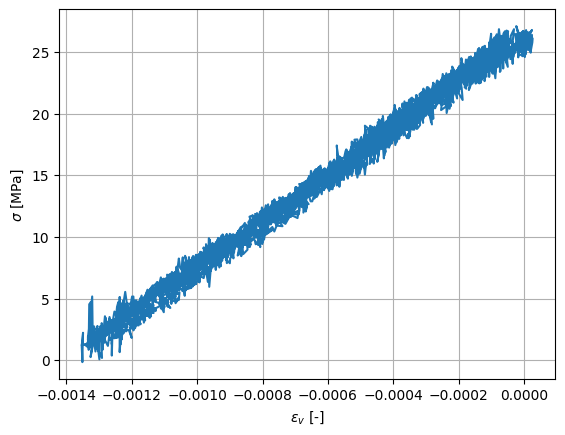

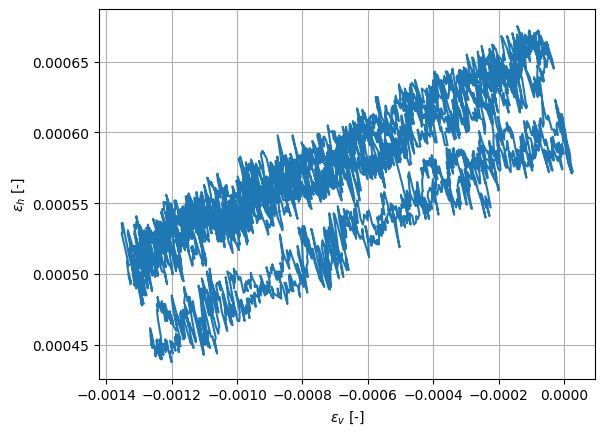

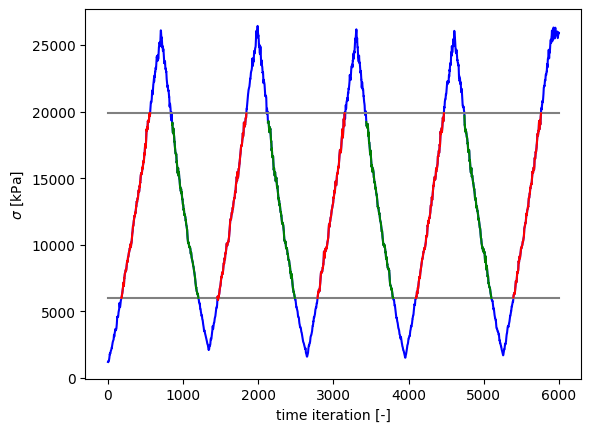

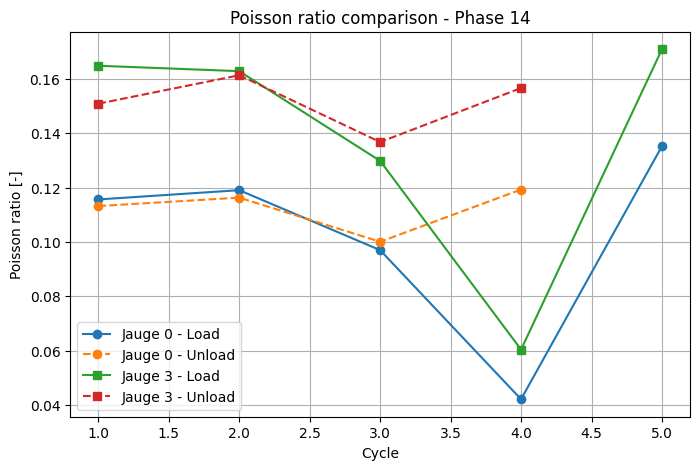

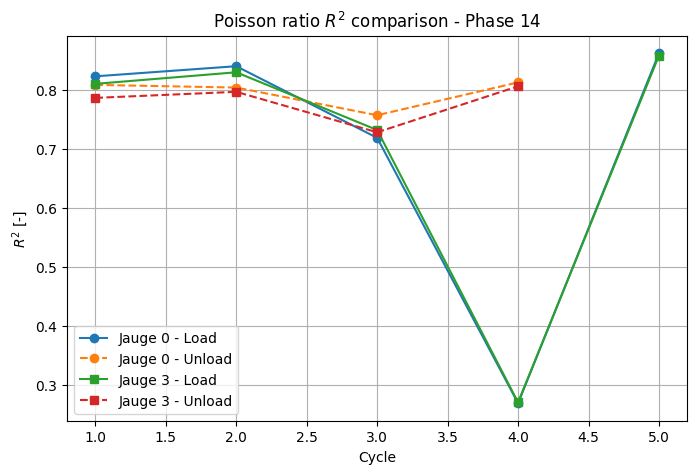

Poisson - Jauge 0: 0.112 - 0.112
Poisson - Jauge 3: 0.15 - 0.152


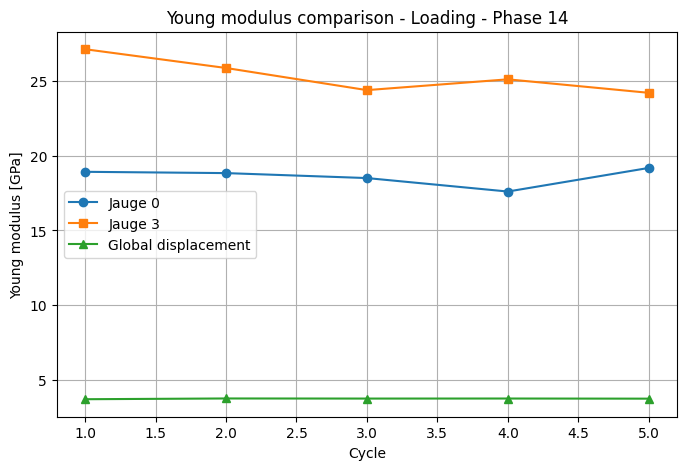

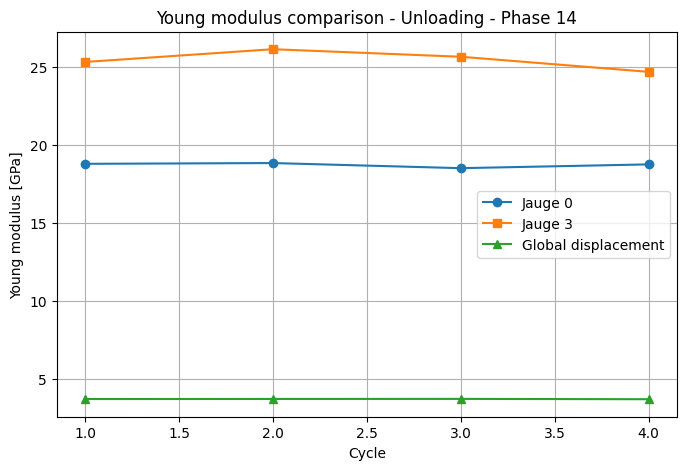

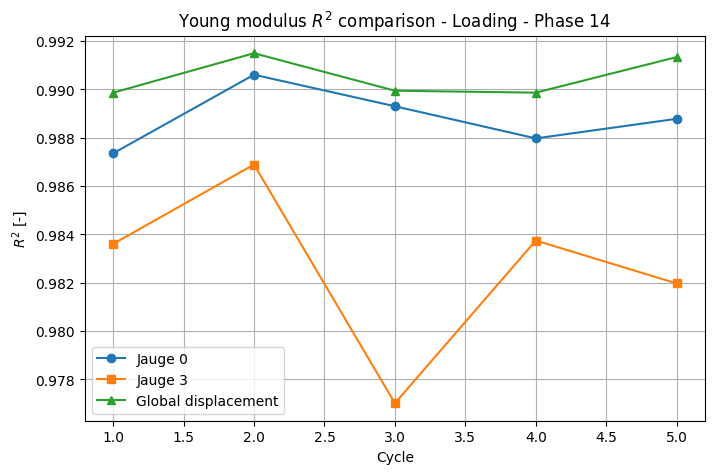

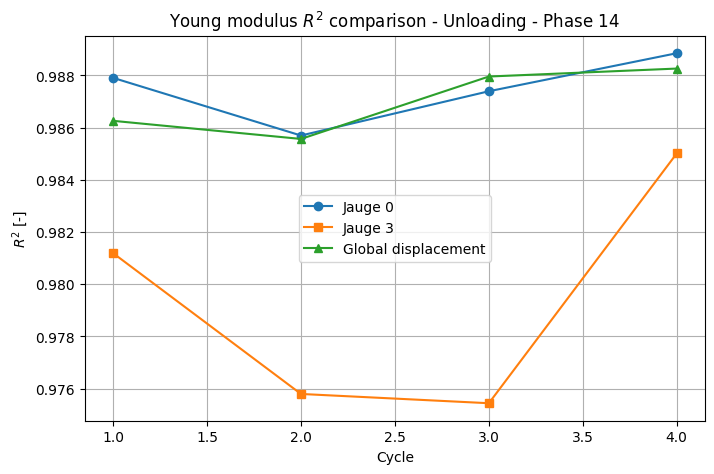

Young - Jauge 0 [GPa]: 18.62 - 18.71
Young - Jauge 3 [GPa]: 25.37 - 25.42
Young - Global [GPa]: 3.72 - 3.73


In [29]:
print('p14:', round(2/section_sample/1e3,2), 'MPa - medium cycles')

# Times selected visually from the global time plot
t0 = 159000  # s
t1 = 172000  # s

# Convert the requested times to the nearest row indices
x0 = nearest_time_index(temps, t0)
x1 = nearest_time_index(temps, t1) + 1

if x1 <= x0:
    raise ValueError(
        f"Invalid time interval: t0={t0}, t1={t1}"
    )

print(
    f"Requested time interval: "
    f"{t0:.2f} s -> {t1:.2f} s"
)

print(
    f"Nearest available times: "
    f"{temps.iloc[x0]:.2f} s -> "
    f"{temps.iloc[x1 - 1]:.2f} s"
)

print(
    f"Corresponding row indices: "
    f"{x0} -> {x1 - 1}"
)

print(
    f"Number of selected rows: "
    f"{x1 - x0}"
)


size_window = 10 # -
delta_data = 250 #
stress_pp, eps_v_pp, eps_v1_pp, eps_vglobal_pp, eps_h_pp = extract_cycles(
    stress,
    size_window,
    delta_data,
    x0,
    x1
)

stress_pp_filter = (
    pd.Series(stress_pp)
    .rolling(window=5, center=True, min_periods=1)
    .median()
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

L_iters_cycle_load, L_iters_cycle_unload = box_min_max(
    stress_pp_filter,
    0.55,
    10,
    5
)

E_l_p14, poisson_l_p14, strain_l_p14, R2_E_l_p14, R2_P_l_p14 = loading(
    eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_load
)

E_u_p14, poisson_u_p14, strain_u_p14, R2_E_u_p14, R2_P_u_p14 = unloading(
    eps_v_pp, eps_h_pp, stress_pp, L_iters_cycle_unload
)

E_l_v3_p14, poisson_l_v3_p14, strain_l_v3_p14, R2_E_l_v3_p14, R2_P_l_v3_p14 = loading(
    eps_v1_pp, eps_h_pp, stress_pp, L_iters_cycle_load
)

E_u_v3_p14, poisson_u_v3_p14, strain_u_v3_p14, R2_E_u_v3_p14, R2_P_u_v3_p14 = unloading(
    eps_v1_pp, eps_h_pp, stress_pp, L_iters_cycle_unload
)

E_l_global_p14, _, strain_l_global_p14, R2_E_l_global_p14, _ = loading(
    eps_vglobal_pp, eps_h_pp, stress_pp, L_iters_cycle_load
)

E_u_global_p14, _, strain_u_global_p14, R2_E_u_global_p14, _ = unloading(
    eps_vglobal_pp, eps_h_pp, stress_pp, L_iters_cycle_unload
)

plt.plot(eps_v[x0:x1], stress[x0:x1]/1e3)
plt.ylabel(r"$\sigma$ [MPa]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

plt.plot(eps_v[x0:x1], eps_h[x0:x1])
plt.ylabel(r"$\epsilon_h$ [-]")
plt.xlabel(r'$\epsilon_v$ [-]')
plt.grid()
plt.show()

plt.plot(stress_pp_filter, color="b")

mean_stress_filter = np.mean(stress_pp_filter)
min_stress_filter = np.min(stress_pp_filter)
max_stress_filter = np.max(stress_pp_filter)

half_amplitude_filter = (
    max_stress_filter - min_stress_filter
) / 2

lower_limit = mean_stress_filter - 0.55 * half_amplitude_filter
upper_limit = mean_stress_filter + 0.55 * half_amplitude_filter

plt.plot(
    [0, len(stress_pp_filter)],
    [lower_limit, lower_limit],
    color="grey"
)

plt.plot(
    [0, len(stress_pp_filter)],
    [upper_limit, upper_limit],
    color="grey"
)

for iters in L_iters_cycle_load:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]:iters[1]+1],
        color='r'
    )

for iters in L_iters_cycle_unload:
    plt.plot(
        range(iters[0], iters[1]+1),
        stress_pp_filter[iters[0]:iters[1]+1],
        color='g'
    )

plt.ylabel(r'$\sigma$ [kPa]')
plt.xlabel(r'time iteration [-]')
plt.show()


# =========================================================
# Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(poisson_l_p14)+1), poisson_l_p14,
         marker='o', linestyle='-', label='Jauge 0 - Load')

plt.plot(np.arange(1, len(poisson_u_p14)+1), poisson_u_p14,
         marker='o', linestyle='--', label='Jauge 0 - Unload')

plt.plot(np.arange(1, len(poisson_l_v3_p14)+1), poisson_l_v3_p14,
         marker='s', linestyle='-', label='Jauge 3 - Load')

plt.plot(np.arange(1, len(poisson_u_v3_p14)+1), poisson_u_v3_p14,
         marker='s', linestyle='--', label='Jauge 3 - Unload')

plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel('Cycle')
plt.title('Poisson ratio comparison - Phase 14')
plt.legend()
plt.show()


# =========================================================
# R² Poisson
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(R2_P_l_p14)+1), R2_P_l_p14,
         marker='o', linestyle='-', label='Jauge 0 - Load')

plt.plot(np.arange(1, len(R2_P_u_p14)+1), R2_P_u_p14,
         marker='o', linestyle='--', label='Jauge 0 - Unload')

plt.plot(np.arange(1, len(R2_P_l_v3_p14)+1), R2_P_l_v3_p14,
         marker='s', linestyle='-', label='Jauge 3 - Load')

plt.plot(np.arange(1, len(R2_P_u_v3_p14)+1), R2_P_u_v3_p14,
         marker='s', linestyle='--', label='Jauge 3 - Unload')

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Poisson ratio $R^2$ comparison - Phase 14')
plt.legend()
plt.show()

print(
    'Poisson - Jauge 0:',
    round(mean_R2(poisson_l_p14, R2_P_l_p14), 3),
    '-',
    round(mean_R2(poisson_u_p14, R2_P_u_p14), 3)
)

print(
    'Poisson - Jauge 3:',
    round(mean_R2(poisson_l_v3_p14, R2_P_l_v3_p14), 3),
    '-',
    round(mean_R2(poisson_u_v3_p14, R2_P_u_v3_p14), 3)
)


# =========================================================
# Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(E_l_p14)+1), np.asarray(E_l_p14)/1e6,
         marker='o', label='Jauge 0')

plt.plot(np.arange(1, len(E_l_v3_p14)+1), np.asarray(E_l_v3_p14)/1e6,
         marker='s', label='Jauge 3')

plt.plot(np.arange(1, len(E_l_global_p14)+1), np.asarray(E_l_global_p14)/1e6,
         marker='^', label='Global displacement')

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Loading - Phase 14')
plt.legend()
plt.show()


# =========================================================
# Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(E_u_p14)+1), np.asarray(E_u_p14)/1e6,
         marker='o', label='Jauge 0')

plt.plot(np.arange(1, len(E_u_v3_p14)+1), np.asarray(E_u_v3_p14)/1e6,
         marker='s', label='Jauge 3')

plt.plot(np.arange(1, len(E_u_global_p14)+1), np.asarray(E_u_global_p14)/1e6,
         marker='^', label='Global displacement')

plt.grid()
plt.ylabel('Young modulus [GPa]')
plt.xlabel('Cycle')
plt.title('Young modulus comparison - Unloading - Phase 14')
plt.legend()
plt.show()


# =========================================================
# R² Young - Chargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(R2_E_l_p14)+1), R2_E_l_p14,
         marker='o', label='Jauge 0')

plt.plot(np.arange(1, len(R2_E_l_v3_p14)+1), R2_E_l_v3_p14,
         marker='s', label='Jauge 3')

plt.plot(np.arange(1, len(R2_E_l_global_p14)+1), R2_E_l_global_p14,
         marker='^', label='Global displacement')

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Loading - Phase 14')
plt.legend()
plt.show()


# =========================================================
# R² Young - Déchargement
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(np.arange(1, len(R2_E_u_p14)+1), R2_E_u_p14,
         marker='o', label='Jauge 0')

plt.plot(np.arange(1, len(R2_E_u_v3_p14)+1), R2_E_u_v3_p14,
         marker='s', label='Jauge 3')

plt.plot(np.arange(1, len(R2_E_u_global_p14)+1), R2_E_u_global_p14,
         marker='^', label='Global displacement')

plt.grid()
plt.ylabel(r'$R^2$ [-]')
plt.xlabel('Cycle')
plt.title(r'Young modulus $R^2$ comparison - Unloading - Phase 14')
plt.legend()
plt.show()

print(
    'Young - Jauge 0 [GPa]:',
    round(mean_R2(E_l_p14, R2_E_l_p14)/1e6, 2),
    '-',
    round(mean_R2(E_u_p14, R2_E_u_p14)/1e6, 2)
)

print(
    'Young - Jauge 3 [GPa]:',
    round(mean_R2(E_l_v3_p14, R2_E_l_v3_p14)/1e6, 2),
    '-',
    round(mean_R2(E_u_v3_p14, R2_E_u_v3_p14)/1e6, 2)
)

print(
    'Young - Global [GPa]:',
    round(mean_R2(E_l_global_p14, R2_E_l_global_p14)/1e6, 2),
    '-',
    round(mean_R2(E_u_global_p14, R2_E_u_global_p14)/1e6, 2)
)

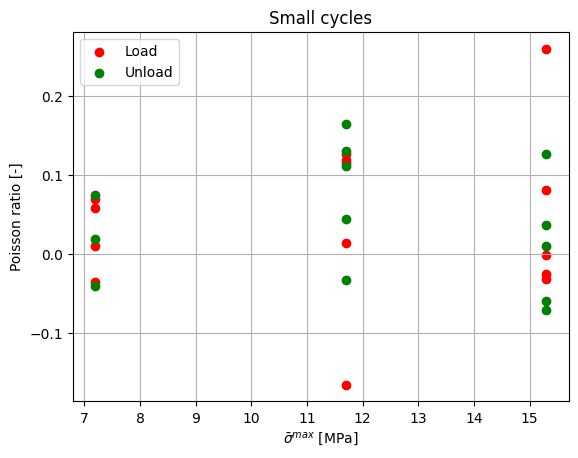

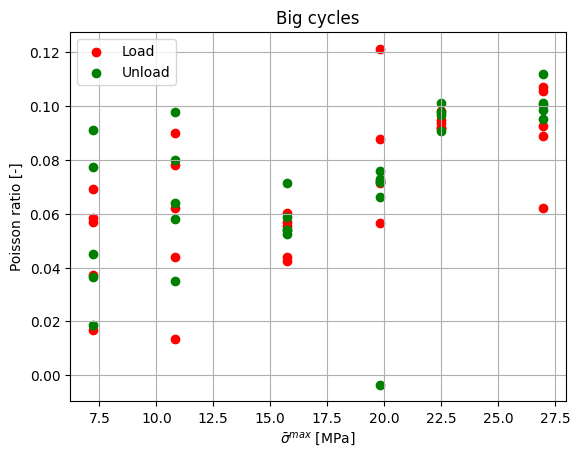

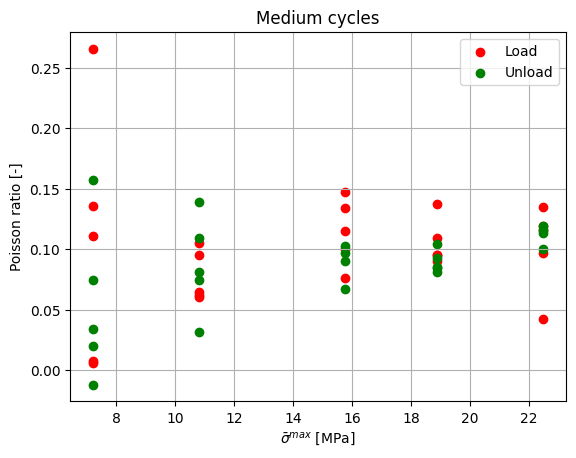

In [30]:
# print poisson

# small cycles
for sm in [1, 3, 6]:
    poisson_l = globals()[f"poisson_l_p{sm}"]
    poisson_u = globals()[f"poisson_u_p{sm}"]
    if sm == 1:
        sigma_l = np.repeat(8/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(poisson_u))
    if sm == 3:
        sigma_l = np.repeat(13/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(13/section_sample/1e3, len(poisson_u))
    if sm == 6:
        sigma_l = np.repeat(17/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(17/section_sample/1e3, len(poisson_u))
    # plot
    plt.scatter(sigma_l, poisson_l, color='r')
    plt.scatter(sigma_u, poisson_u, color='g')
plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Small cycles')
plt.legend(["Load", "Unload"])
plt.show()


# large cycle
for sm in [2, 4, 7, 9, 11, 13]:
    poisson_l = globals()[f"poisson_l_p{sm}"]
    poisson_u = globals()[f"poisson_u_p{sm}"]
    if sm == 2:
        sigma_l = np.repeat(8/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(poisson_u))
    if sm == 4:
        sigma_l = np.repeat(12/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(12/section_sample/1e3, len(poisson_u))
    if sm == 7:
        sigma_l = np.repeat(17.5/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(17.5/section_sample/1e3, len(poisson_u))
    if sm == 9:
        sigma_l = np.repeat(22/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(22/section_sample/1e3, len(poisson_u))
    if sm == 11:
        sigma_l = np.repeat(25/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(25/section_sample/1e3, len(poisson_u))
    if sm == 13:
        sigma_l = np.repeat(30/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(30/section_sample/1e3, len(poisson_u))
    plt.scatter(sigma_l, poisson_l, color='r')
    plt.scatter(sigma_u, poisson_u, color='g')
plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Big cycles')
plt.legend(["Load", "Unload"])
plt.show()

# medium cycle
for sm in [5, 8, 10, 12, 14]:
    poisson_l = globals()[f"poisson_l_p{sm}"]
    poisson_u = globals()[f"poisson_u_p{sm}"]
    if sm == 5:
        sigma_l = np.repeat(8/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(poisson_u))
    if sm == 8:
        sigma_l = np.repeat(12/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(12/section_sample/1e3, len(poisson_u))
    if sm == 10:
        sigma_l = np.repeat(17.5/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(17.5/section_sample/1e3, len(poisson_u))
    if sm == 12:
        sigma_l = np.repeat(21/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(21/section_sample/1e3, len(poisson_u))
    if sm == 14:
        sigma_l = np.repeat(25/section_sample/1e3, len(poisson_l))
        sigma_u = np.repeat(25/section_sample/1e3, len(poisson_u))
    plt.scatter(sigma_l, poisson_l, color='r')
    plt.scatter(sigma_u, poisson_u, color='g')
plt.grid()
plt.ylabel('Poisson ratio [-]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Medium cycles')
plt.legend(["Load", "Unload"])
plt.show()

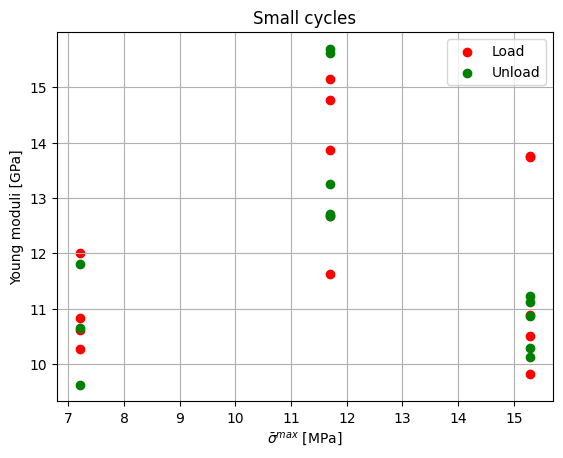

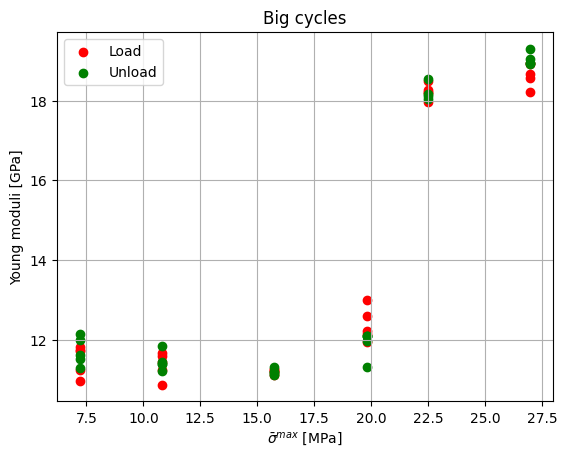

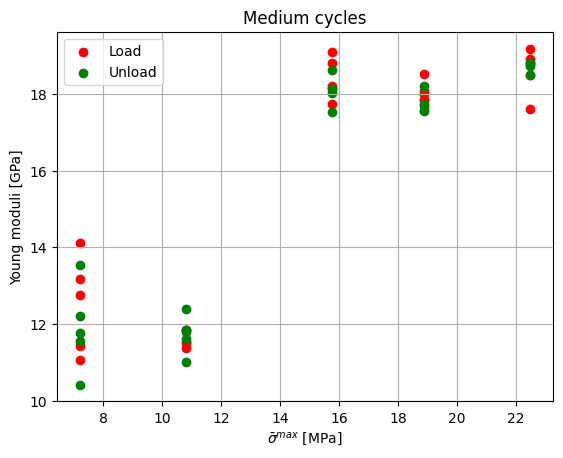

In [31]:
# print Young

# small cycle
for sm in [1, 3, 6]:
    E_l = np.array(globals()[f"E_l_p{sm}"])/1e6
    E_u =  np.array(globals()[f"E_u_p{sm}"])/1e6
    if sm == 1:
        sigma_l = np.repeat(8/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(E_u))
    if sm == 3:
        sigma_l = np.repeat(13/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(13/section_sample/1e3, len(E_u))
    if sm == 6:
        sigma_l = np.repeat(17/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(17/section_sample/1e3, len(E_u))
    plt.scatter(sigma_l, E_l, color='r')
    plt.scatter(sigma_u, E_u, color='g')
plt.grid()
plt.ylabel('Young moduli [GPa]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Small cycles')
plt.legend(["Load", "Unload"])
plt.show()


# large cycle
for sm in [2, 4, 7, 9, 11, 13]:
    E_l = np.array(globals()[f"E_l_p{sm}"])/1e6
    E_u =  np.array(globals()[f"E_u_p{sm}"])/1e6
    if sm == 2:
        sigma_l = np.repeat(8/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(E_u))
    if sm == 4:
        sigma_l = np.repeat(12/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(12/section_sample/1e3, len(E_u))
    if sm == 7:
        sigma_l = np.repeat(17.5/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(17.5/section_sample/1e3, len(E_u))
    if sm == 9:
        sigma_l = np.repeat(22/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(22/section_sample/1e3, len(E_u))
    if sm == 11:
        sigma_l = np.repeat(25/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(25/section_sample/1e3, len(E_u))
    if sm == 13:
        sigma_l = np.repeat(30/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(30/section_sample/1e3, len(E_u))
    plt.scatter(sigma_l, E_l, color='r')
    plt.scatter(sigma_u, E_u, color='g')
plt.grid()
plt.ylabel('Young moduli [GPa]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Big cycles')
plt.legend(["Load", "Unload"])
plt.show()


# medium cycle
for sm in [5, 8, 10, 12, 14]:
    E_l = np.array(globals()[f"E_l_p{sm}"])/1e6
    E_u =  np.array(globals()[f"E_u_p{sm}"])/1e6
    if sm == 5:
        sigma_l = np.repeat(8/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(8/section_sample/1e3, len(E_u))
    if sm == 8:
        sigma_l = np.repeat(12/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(12/section_sample/1e3, len(E_u))
    if sm == 10:
        sigma_l = np.repeat(17.5/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(17.5/section_sample/1e3, len(E_u))
    if sm == 12:
        sigma_l = np.repeat(21/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(21/section_sample/1e3, len(E_u))
    if sm == 14:
        sigma_l = np.repeat(25/section_sample/1e3, len(E_l))
        sigma_u = np.repeat(25/section_sample/1e3, len(E_u))
    plt.scatter(sigma_l, E_l, color='r')
    plt.scatter(sigma_u, E_u, color='g')
plt.grid()
plt.ylabel('Young moduli [GPa]')
plt.xlabel(r'$\bar{\sigma}^{max}$ [MPa]')
plt.title('Medium cycles')
plt.legend(["Load", "Unload"])
plt.show()